# Семинар 4. Модель как исполнитель разметки


Сегодня на практике попробуем **размечать данные моделью** — так же, как это делают люди в краудсорсинге, но с промптом, порогом уверенности и гибридными схемами.


Возьмём один датасет — посты ВКонтакте с тональностью — и пройдём весь цикл: посмотрим на данные, сравним людей и модель, попробуем разные промпты, подберём порог «модель / человек» и соберём итоговую таблицу по качеству, стоимости и скорости.


## Содержание


1. **Датасет и протокол** — что в таблице, как фиксируем `task_id`, сплиты, дубли и утечки.
2. **Человеческая разметка** — как устроены Яндекс Задания, перекрытие, majority vote, качество исполнителей.
3. **Открытые вопросы** — зачем датасет, зачем модели, чем автоматизировать.
4. **Hugging Face и промпт** — локальный инференс, сборка промпта по частям, абляция на нескольких примерах.
5. **Prompt ladder** — zero-shot, few-shot, reasoning, structured; сравнение с людьми.
6. **Уверенность и гибрид** — порог на калибровке, модель вместо одного исполнителя, пять схем маршрутизации.
7. **Ансамбль и итог** — несколько моделей, споры, majority vote, leaderboard.


## Что понадобится сегодня


| Ресурс | Ссылка | Зачем |
|---|---|---|
| Данные семинара (GitHub) | [github.com/MilordEv/seminar4-model-as-annotator-data](https://github.com/MilordEv/seminar4-model-as-annotator-data) | `data/` и `artifacts/` — ноутбук скачает сам |
| Google Colab | [colab.research.google.com](https://colab.research.google.com/) | можно запускать ноутбук в облаке |
| Датасет RuSentiment | [github.com/strawberrypie/rusentiment](https://github.com/strawberrypie/rusentiment) | исходный корпус; у нас — подвыборка в `data/dataset.csv` |
| Hugging Face | [huggingface.co](https://huggingface.co/) | локальный инференс при сборке промпта и в блоке 4 (опционально — токен в `.env`) |
| Яндекс Задания | [tasks.yandex.ru](https://tasks.yandex.ru/) | схема человеческой разметки (на занятии читаем готовые ответы) |


### Папки `data/` и `artifacts/`


При первом запуске ноутбук **скачивает** их из [репозитория на GitHub](https://github.com/MilordEv/seminar4-model-as-annotator-data). Ручная установка не обязательна — достаточно открыть `seminar.ipynb` (локально или в Colab).


- **`data/`** — исходники: таблица постов (`dataset.csv`), инструкция для исполнителей (`instruction.html`), описание корпуса (`SOURCE.md`), схемы.


- **`artifacts/`** — готовые результаты эксперимента: сплиты, ответы людей, предсказания моделей, журнал вызовов. На занятии их не пересчитываем.


Файл **`.env.example`** скопируйте в **`.env`**, если нужны живые вызовы API (ключи в вывод не попадают).


## 0. Установка библиотек


Запустите ячейку один раз в новом окружении. После установки, если ядро просит, сделайте Restart Kernel и продолжайте со следующей ячейки.


`torch` / `transformers` нужны только если включите `RUN_LIVE_HF`.


In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn pyarrow openpyxl python-dotenv requests tqdm

# Только для живого локального инференса (RUN_LIVE_HF = True):
# %pip install torch transformers accelerate


## Импорты


In [2]:
# Стандартный набор библиотек занятия. torch/transformers подгрузятся только в ячейке RUN_LIVE_HF.

import hashlib
import json
import os
import re
import time
import unicodedata
import warnings
from datetime import datetime, timedelta, timezone
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import HTML, Markdown, display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

from sklearn.model_selection import train_test_split
from typing import Any, Sequence


## Пути, секреты и флаги запуска


Ключи — в `.env` (шаблон: `.env.example`). Ядро Jupyter запускайте из папки семинара.


In [3]:
# Секреты из .env, в вывод ячейки не печатаем сами ключи.

load_dotenv()

# «Дорогие» действия выключены. Включайте по одному, если нужен живой прогон.

RUN_LIVE_HF = True           # True → живой HF-инференс в блоках 3–5
RUN_REBUILD_ARTIFACTS = True # True + RUN_LIVE_HF → ещё сохранить model_predictions.parquet и call_log
RUN_YATASKS = False           # создание проекта/пула, на занятии не включаем

# Ядро Jupyter — из папки семинара или Colab (/content). data/ и artifacts/ подтягиваются с GitHub.

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACTS_DIR = ROOT / "artifacts"

GITHUB_DATA_REPO = "MilordEv/seminar4-model-as-annotator-data"
GITHUB_DATA_REF = "main"


def download_seminar_data(root: Path) -> None:
    # Скачать data/ и artifacts/ из GitHub, если локально ещё нет split_manifest.json.

    marker = root / "artifacts" / "split_manifest.json"
    if marker.exists():
        return
    import io
    import zipfile

    repo_name = GITHUB_DATA_REPO.split("/")[-1]
    url = f"https://github.com/{GITHUB_DATA_REPO}/archive/refs/heads/{GITHUB_DATA_REF}.zip"
    print("скачиваем data/ и artifacts/ из GitHub:", url)
    response = requests.get(url, timeout=180)
    response.raise_for_status()
    archive = zipfile.ZipFile(io.BytesIO(response.content))
    prefix = f"{repo_name}-{GITHUB_DATA_REF}/"
    for member in archive.namelist():
        if not (member.startswith(prefix + "data/") or member.startswith(prefix + "artifacts/")):
            continue
        rel = member[len(prefix) :]
        target = root / rel
        if member.endswith("/"):
            target.mkdir(parents=True, exist_ok=True)
            continue
        target.parent.mkdir(parents=True, exist_ok=True)
        target.write_bytes(archive.read(member))
    if not marker.exists():
        raise FileNotFoundError(f"После загрузки не найден {marker}. Проверьте репозиторий {GITHUB_DATA_REPO}.")
    print("готово:", root / "data", "|", root / "artifacts")


download_seminar_data(ROOT)


def show_data_image(filename: str, width: int = 720) -> None:
    # Картинки лежат в DATA_DIR — так работает и локально, и после скачивания с GitHub.

    from IPython.display import Image, display

    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"нет файла {path}")
    display(Image(filename=str(path), width=width))


# Имена файлов фиксированы: так ноутбук не зависит от того, кто как назвал выгрузку.

FILES = {
    "dataset": DATA_DIR / "dataset.csv",
    "instruction": DATA_DIR / "instruction.html",
    "dataset_prepared": ARTIFACTS_DIR / "dataset_prepared.parquet",
    "split_manifest": ARTIFACTS_DIR / "split_manifest.json",
    "human_answers": ARTIFACTS_DIR / "human_answers.parquet",
    "human_aggregation": ARTIFACTS_DIR / "human_aggregation.parquet",
    "model_predictions": ARTIFACTS_DIR / "model_predictions.parquet",
    "ensemble_predictions": ARTIFACTS_DIR / "ensemble_predictions.parquet",
    "call_log": ARTIFACTS_DIR / "call_log.parquet",
    "yatasks_entities": ARTIFACTS_DIR / "yatasks_entities.json",
    "leaderboard": ARTIFACTS_DIR / "leaderboard.csv",  # этот файл ноутбук сам запишет в конце
}

sns.set_theme(style="whitegrid", font_scale=1.05)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 140)
warnings.filterwarnings("ignore", category=FutureWarning)

optional_if_rebuild = {"dataset_prepared", "split_manifest"} if RUN_REBUILD_ARTIFACTS else set()
optional_if_live_hf = {"model_predictions", "call_log"} if RUN_LIVE_HF else set()
missing = [
    name
    for name, path in FILES.items()
    if name != "leaderboard"
    and name not in optional_if_rebuild
    and name not in optional_if_live_hf
    and not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Не хватает файлов: "
        + ", ".join(f"{name} → {FILES[name]}" for name in missing)
        + f". Проверьте доступ к https://github.com/{GITHUB_DATA_REPO} или скачайте репозиторий вручную."
    )


def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")


print("cwd:", ROOT)
print("OPENROUTER_API_KEY set:", bool(os.environ.get("OPENROUTER_API_KEY")))
print("YATASKS_TOKEN set:", bool(os.environ.get("YATASKS_TOKEN") or os.environ.get("TOKEN")))
print("HF_TOKEN set:", bool(os.environ.get("HF_TOKEN")))
print("artifacts:", sorted(p.name for p in ARTIFACTS_DIR.iterdir()))


скачиваем data/ и artifacts/ из GitHub: https://github.com/MilordEv/seminar4-model-as-annotator-data/archive/refs/heads/main.zip
готово: /content/data | /content/artifacts
cwd: /content
OPENROUTER_API_KEY set: False
YATASKS_TOKEN set: False
HF_TOKEN set: False
artifacts: ['call_log.parquet', 'dataset_prepared.parquet', 'ensemble_predictions.parquet', 'human_aggregation.parquet', 'human_answers.parquet', 'leaderboard.csv', 'model_predictions.parquet', 'split_manifest.json', 'yatasks_entities.json']


# Блок 1. Датасет и фиксация протокола


Работаем с подвыборкой [RuSentiment](https://github.com/strawberrypie/rusentiment) — корпуса тональности постов ВКонтакте. Описание задачи и меток — в статье [RuSentiment: An Annotated Sentiment Analysis Dataset for Russian](https://aclanthology.org/C18-1064/) (ACL 2018).


In [4]:
raw_csv = pd.read_csv(FILES["dataset"])

print("строк:", len(raw_csv))
print("колонки:", list(raw_csv.columns))

raw_csv.head(8)


строк: 260
колонки: ['text', 'label', 'source', 'hint']


,text,label,source,hint
0,"Огоооооо) \nНечего себеее)\nЯ что то пропустила,дорогая?",positive,rusentiment_random,Явная или подразумеваемая позитивная оценка либо настроение. Желание чего-то — тоже positive.
1,я не сомневалась в вас молодцы),positive,rusentiment_random,Явная или подразумеваемая позитивная оценка либо настроение. Желание чего-то — тоже positive.
2,"Фууу, опять надоевшая ссаная Германия проходит. Поражений во всех следующих матчах!",negative,rusentiment_random,"Явная или подразумеваемая негативная оценка либо настроение, включая сарказм."
3,поздровляем что ты блядь,negative,rusentiment_random,"Явная или подразумеваемая негативная оценка либо настроение, включая сарказм."
4,"Ребята которые идут на нас посмотреть 15 числа - мне надо с вас по 300 р собрать за билеты, нам их выкупать надо! Спасибо",neutral,rusentiment_random,"Факт, вопрос, реклама или описание без тональности. Смайлик сам по себе не делает пост тональным."
5,"Кто имеет уши слышать, да слышит! (Св. Евангелие от Матфея, глава 13)",neutral,rusentiment_random,"Факт, вопрос, реклама или описание без тональности. Смайлик сам по себе не делает пост тональным."
6,С Рождеством друзья =),speech,rusentiment_random,"Поздравление, благодарность, приветствие или пожелание — речевой акт, даже если он «позитивный»."
7,С днём рождения Тима!))),speech,rusentiment_random,"Поздравление, благодарность, приветствие или пожелание — речевой акт, даже если он «позитивный»."


Сколько объектов по источникам и по меткам. Рядом — распределение классов.


источники:


,n
source,
rusentiment_test,200
rusentiment_random,60


метки:


,n
label,
positive,52
negative,52
neutral,52
speech,52
skip,52


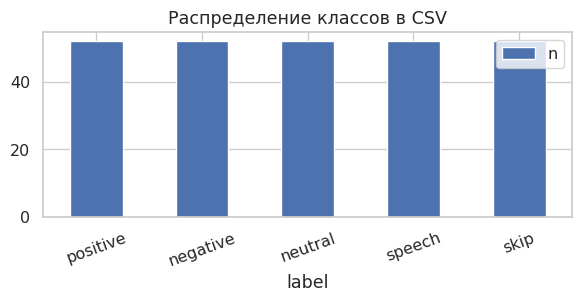

In [5]:
print("источники:")
display(raw_csv["source"].value_counts().to_frame("n"))

print("метки:")
label_counts = raw_csv["label"].value_counts().to_frame("n")
display(label_counts)

label_counts.plot(kind="bar", figsize=(6, 3.2), rot=20, title="Распределение классов в CSV")
plt.tight_layout()
plt.show()


По одному примеру на класс — так видно, чем `speech` отличается от `positive`, а `skip` от `neutral`.


In [6]:
for label in ["positive", "negative", "neutral", "speech", "skip"]:
    row = raw_csv.loc[raw_csv["label"] == label].iloc[0]
    print(f"[{label}] {row['text']}")
    print("---")


[positive] Огоооооо) 
Нечего себеее)
Я что то пропустила,дорогая?
---
[negative] Фууу, опять надоевшая ссаная Германия проходит. Поражений во всех следующих матчах!
---
[neutral] Ребята которые идут на нас посмотреть 15 числа - мне надо с вас по 300 р собрать за билеты, нам их выкупать надо! Спасибо
---
[speech] С Рождеством друзья =)
---
[skip] Все идут по улице с девушками,а я с сумкой после тренеровки...Я  бы поспорил кому повезло больше...))
---


## Контракт данных


Чтобы люди, модель и гибрид сравнивались по одним объектам, нужны стабильный `task_id`, конечный список классов и одни и те же имена сплитов. Сырой CSV называет метку `label` — дальше везде будет `golden_label`.


In [7]:
# --- Контракт семинара ---------------------------------------------------------
# Эти константы — договор между датасетом, людьми и моделью.
# Менять тексты постов можно, набор классов и имена сплитов лучше не ломать:
# иначе метрики разных схем перестанут быть сопоставимыми.

# Ровно эти пять строк модель и человек имеют право вернуть.

LABELS = ("positive", "negative", "neutral", "speech", "skip")
RANDOM_STATE = 42  # один seed на всех, чтобы у группы совпали сплиты

LABEL_RU = {
    "positive": "позитив",
    "negative": "негатив",
    "neutral": "без тональности",
    "speech": "речевой акт",
    "skip": "пропуск",
}

# Что обязано быть в таблице, даже если завтра подложат другой корпус.

DATA_CONTRACT = {
    "id_col": "task_id",
    "text_col": "text",
    "context_cols": [],
    "label_col": "golden_label",
    "classes": list(LABELS),
    "splits": ["prompt_examples", "calibration", "test"],
    "dataset": "RuSentiment",
}


In [8]:
print("классы, которые имеют право вернуть и человек, и модель:")
print(LABELS)

display(DATA_CONTRACT)


классы, которые имеют право вернуть и человек, и модель:
('positive', 'negative', 'neutral', 'speech', 'skip')


{'id_col': 'task_id',
 'text_col': 'text',
 'context_cols': [],
 'label_col': 'golden_label',
 'classes': ['positive', 'negative', 'neutral', 'speech', 'skip'],
 'splits': ['prompt_examples', 'calibration', 'test'],
 'dataset': 'RuSentiment'}

### `task_id`


In [9]:
# ---------------------------------------------------------------------------
# Stable task identifiers
# ---------------------------------------------------------------------------

def make_task_id(*parts: Any) -> str:
    """Стабильный id объекта разметки: одинаковый текст → один и тот же id."""
    blob = "||".join("" if p is None else str(p).strip() for p in parts)
    digest = hashlib.sha1(blob.encode("utf-8")).hexdigest()[:12]
    return f"task_{digest}"


In [10]:
preview = raw_csv[["text", "label"]].head(3).copy()
preview["task_id"] = preview["text"].map(make_task_id)

display(preview)


,text,label,task_id
0,"Огоооооо) \nНечего себеее)\nЯ что то пропустила,дорогая?",positive,task_5b3280bca68e
1,я не сомневалась в вас молодцы),positive,task_d932a603f4eb
2,"Фууу, опять надоевшая ссаная Германия проходит. Поражений во всех следующих матчах!",negative,task_24b99d5ffc88


### Нормализация


In [11]:
# ---------------------------------------------------------------------------
# Dataset contract
# ---------------------------------------------------------------------------

def _rename_toloka_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Выгрузки Яндекс Заданий приходят с префиксами INPUT:/GOLDEN: — сглаживаем."""
    mapping = {}
    for col in df.columns:
        lowered = col.strip()
        if lowered.startswith("INPUT:"):
            mapping[col] = lowered.split(":", 1)[1]
        elif lowered in {"GOLDEN:result", "OUTPUT:result", "verdict", "label"}:
            mapping[col] = "golden_label"
        elif lowered in {"HINT:text", "HINT:default"}:
            mapping[col] = "hint"
        elif lowered in {"review_text", "post", "post_text"}:
            mapping[col] = "text"
    return df.rename(columns=mapping)


def normalize_dataset(df: pd.DataFrame, source: str) -> pd.DataFrame:
    """Привести сырую таблицу к полям семинара: text, golden_label, task_id.

    Дальше весь ноутбук работает только с этим контрактом, а не с именами
    колонок исходного CSV.
    """
    out = _rename_toloka_columns(df).copy()
    if "text" not in out.columns:
        raise ValueError(f"{source}: missing column 'text'. Have {list(out.columns)}")

    for col in ["text", "golden_label", "hint", "source"]:
        if col in out.columns:
            out[col] = out[col].fillna("").astype(str).str.strip()

    if "golden_label" in out.columns:
        out["golden_label"] = out["golden_label"].str.lower()
        unexpected = set(out["golden_label"].unique()) - set(LABELS) - {""}
        if unexpected:
            # Лучше упасть сразу, чем тихо смешать «Positive» и «позитив» в метриках.

            raise ValueError(f"{source}: unexpected labels {unexpected}")
        out.loc[out["golden_label"] == "", "golden_label"] = np.nan
    else:
        out["golden_label"] = np.nan

    if "hint" not in out.columns:
        out["hint"] = ""
    if "source" not in out.columns or (out["source"] == "").all():
        out["source"] = source
    else:
        out["source"] = out["source"].replace("", source)

    # Id считаем от текста: одно и то же сообщение из разных файлов не раздвоится.

    out["task_id"] = [make_task_id(t) for t in out["text"]]
    out["text_len_chars"] = out["text"].str.len()
    out["text_len_tokens_est"] = out["text"].str.split().str.len()
    out["n_hashtags"] = out["text"].str.count(r"#\w+")
    return out[
        [
            "task_id",
            "source",
            "text",
            "golden_label",
            "hint",
            "text_len_chars",
            "text_len_tokens_est",
            "n_hashtags",
        ]
    ]


def load_current_dataset() -> pd.DataFrame:
    """Прочитать data/dataset.csv и сразу привести к контракту."""
    root = data_dir()
    csv_path = root / RAW_FILES["dataset"]
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Нет {csv_path}. Положите подвыборку RuSentiment как data/dataset.csv "
            "(колонки text, label) или запустите prepare_dataset.py."
        )
    data = normalize_dataset(pd.read_csv(csv_path), "dataset")
    data = data.drop_duplicates(subset=["task_id"]).reset_index(drop=True)
    return data


In [12]:
raw = normalize_dataset(raw_csv, "dataset")

print("строк до дедупа:", len(raw))
raw = raw.drop_duplicates(subset=["task_id"]).reset_index(drop=True)
print("строк после дедупа по task_id:", len(raw))

print("колонки:", list(raw.columns))
raw[["task_id", "source", "text", "golden_label", "text_len_chars"]].head(5)


строк до дедупа: 260
строк после дедупа по task_id: 260
колонки: ['task_id', 'source', 'text', 'golden_label', 'hint', 'text_len_chars', 'text_len_tokens_est', 'n_hashtags']


,task_id,source,text,golden_label,text_len_chars
0,task_5b3280bca68e,rusentiment_random,"Огоооооо) \nНечего себеее)\nЯ что то пропустила,дорогая?",positive,54
1,task_d932a603f4eb,rusentiment_random,я не сомневалась в вас молодцы),positive,31
2,task_24b99d5ffc88,rusentiment_random,"Фууу, опять надоевшая ссаная Германия проходит. Поражений во всех следующих матчах!",negative,83
3,task_8e67dc5b93d0,rusentiment_random,поздровляем что ты блядь,negative,24
4,task_fd199e1a7fa7,rusentiment_random,"Ребята которые идут на нас посмотреть 15 числа - мне надо с вас по 300 р собрать за билеты, нам их выкупать надо! Спасибо",neutral,121


### Точные дубликаты


Проверяем, не размножился ли один пост под разными строками CSV.


In [13]:
n_dup_rows = int(raw.duplicated(subset=["task_id"]).sum())
n_unique = raw["task_id"].nunique()

print("строк:", len(raw))
print("уникальных task_id:", n_unique)
print("дубликатов по task_id:", n_dup_rows)

if n_dup_rows:
    display(raw[raw.duplicated(subset=["task_id"], keep=False)].sort_values("task_id").head(10))
else:
    print("точных дублей по task_id нет")


строк: 260
уникальных task_id: 260
дубликатов по task_id: 0
точных дублей по task_id нет


### Длины и пропуски


In [14]:
print("пустой текст:", int((raw["text"] == "").sum()))
print("нет эталона:", int(raw["golden_label"].isna().sum()))

display(raw["text_len_chars"].describe().to_frame("chars"))


пустой текст: 0
нет эталона: 0


,chars
count,260.000000
mean,91.423077
std,130.380427
min,10.000000
25%,24.000000
50%,46.500000
75%,99.500000
max,750.000000


### Длина по классам


In [15]:
print("длина текста по golden_label (символы):")
len_by_class = raw.groupby("golden_label")["text_len_chars"].describe().round(1)
display(len_by_class)


длина текста по golden_label (символы):


,count,mean,std,min,25%,50%,75%,max
golden_label,,,,,,,,
negative,52.0,136.4,177.9,12.0,35.8,65.0,139.2,705.0
neutral,52.0,78.6,102.0,10.0,24.5,46.5,77.0,564.0
positive,52.0,51.3,50.0,10.0,20.8,36.0,58.2,283.0
skip,52.0,88.8,140.1,10.0,19.0,42.5,97.5,750.0
speech,52.0,102.1,134.7,10.0,23.5,43.5,117.8,542.0


Примеры `negative` — часто короткие и с сарказмом; длина сама по себе не определяет класс.


In [16]:
neg_examples = raw.loc[raw["golden_label"] == "negative", ["task_id", "text_len_chars", "text"]].head(5)
print("примеры negative (первые 5):")
display(neg_examples)


примеры negative (первые 5):


,task_id,text_len_chars,text
2,task_24b99d5ffc88,83,"Фууу, опять надоевшая ссаная Германия проходит. Поражений во всех следующих матчах!"
3,task_8e67dc5b93d0,24,поздровляем что ты блядь
20,task_a999d8a62eac,108,"Даже самая верная и любящая устанет ждать, если постоянно будет чувствовать холод и равнодушие в свой адрес."
21,task_88be1391f6b4,140,Мне плохо и тяжело. Этого не должно было случиться. Это как потерять родного человека. Кузьма. Скрябин. Андрей. Человек! Все слова - бре...
22,task_75b38520ff28,25,И вообще! Я соскучилась:<


p95 длины: 386 символов


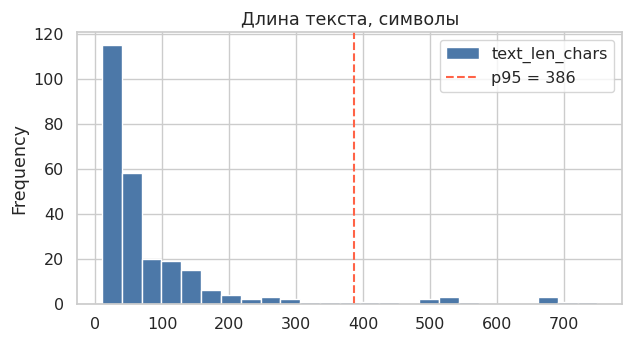

In [17]:
p95 = raw["text_len_chars"].quantile(0.95)
print("p95 длины:", int(p95), "символов")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
raw["text_len_chars"].plot(kind="hist", bins=25, ax=ax, color="#4c78a8", title="Длина текста, символы")
ax.axvline(p95, color="tomato", linestyle="--", label=f"p95 = {int(p95)}")
ax.legend()
plt.tight_layout()
plt.show()


Самые длинные посты — проверяем, не ошибка ли загрузки.


In [18]:
long_tail = raw.nlargest(5, "text_len_chars")[
    ["task_id", "source", "golden_label", "text_len_chars", "text"]
]

print("топ-5 по длине:")
display(long_tail.assign(text_preview=long_tail["text"].str.slice(0, 180) + "…")[["task_id", "source", "golden_label", "text_len_chars", "text_preview"]])


топ-5 по длине:


,task_id,source,golden_label,text_len_chars,text_preview
232,task_50a1e0df3ec9,rusentiment_test,skip,750,"Не тратьте жизнь на тех, кто вас не ценит,\nНа тех, кто вас не любит и не ждёт,\nНа тех, кто без сомнений вам изменит,\nКто вдруг пойдёт..."
106,task_ac9a12ad99c6,rusentiment_test,negative,705,Вот за такие статьи журналистов нужно наказывать!!!! Я был на той реконструкции и праздновали там победу над фашистами. А журналисты все...
29,task_bf79b413b446,rusentiment_random,negative,683,[id26131921|Лизуня]\nнахуй!!!! 24.09.11\n [id83260700|Кирилл]\nахахах...школота школота... 24.09.11\n [id26131921|Лизуня]\nты блять сам ...
117,task_010b21d66d72,rusentiment_test,negative,682,"С одной стороны - приятно узнать, что не один ты не веришь в эту особую ""темную материю"". Бальзам на раны, так сказать... Но с другой......"
101,task_155565cc7469,rusentiment_test,negative,676,у СОВРЕМЕННОЙ ЭКОНОМИКИ НЕТ НИКАКОЙ ЭКОНОМИКИ ГОСУДАРСТВЕННОЙ. МНЕ РАБОЧЕЙ ОТ ТОКАРНОГО СТАНКА СОЗДАЮЩЕЙ СОБСТВЕННЫМИ РУКАМИ МАТЕРИА...


Короткие посты — не мусор для вычищения из test, а трудные случаи. Их нельзя выкидывать только из оценки, иначе сравнение станет нечестно лёгким.


In [19]:
short = raw.loc[raw["text_len_chars"] <= 25, ["task_id", "text", "golden_label", "text_len_chars"]]

print("постов ≤ 25 символов:", len(short))
display(short.head(8))


постов ≤ 25 символов: 74


,task_id,text,golden_label,text_len_chars
3,task_8e67dc5b93d0,поздровляем что ты блядь,negative,24
6,task_9ec6a26aea5a,С Рождеством друзья =),speech,22
7,task_d8b80d3f2314,С днём рождения Тима!))),speech,24
17,task_e538ebb99283,Люблю-жить!!!!!,positive,15
18,task_3aa5fd94c9c9,"любить себя , лучше!",positive,20
22,task_75b38520ff28,И вообще! Я соскучилась:<,negative,25
28,task_7fc875de241a,не ты охренела или что?),negative,24
31,task_4a35d10314f9,приходите!! мы ждем Вас!!,neutral,25


### Графики длины по меткам


Сохраняем в `data/plots/` — те же файлы можно открыть в браузере (`data/plots/view.html`).


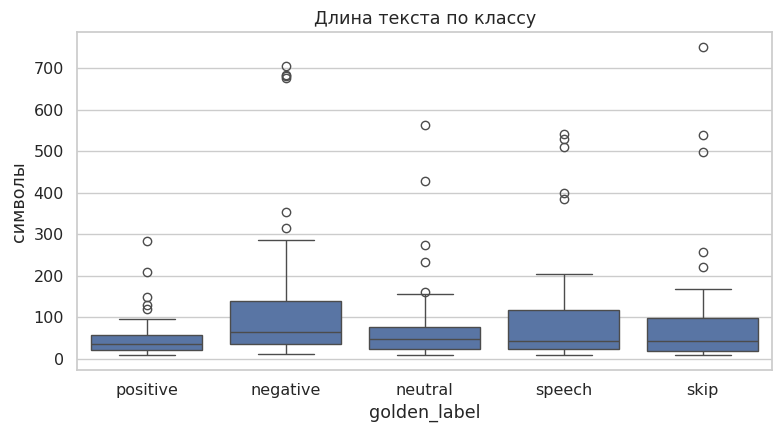

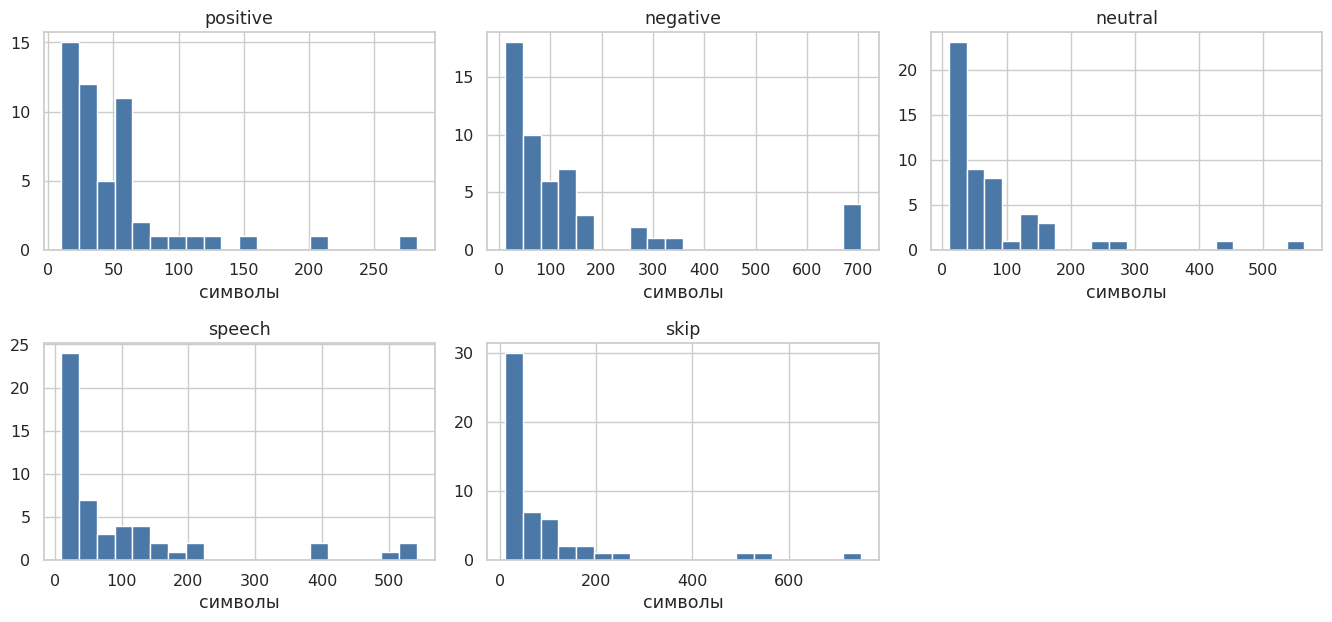

сохранено: /content/data/plots/label_length_boxplot.png | /content/data/plots/label_length_hist_grid.png


In [20]:
plots_dir = DATA_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

label_order = [c for c in LABELS if c in raw["golden_label"].unique()]
plot_df = raw.dropna(subset=["golden_label"])

box_path = plots_dir / "label_length_boxplot.png"
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=plot_df, x="golden_label", y="text_len_chars", order=label_order, ax=ax)
ax.set_title("Длина текста по классу")
ax.set_xlabel("golden_label")
ax.set_ylabel("символы")
plt.tight_layout()
fig.savefig(box_path, dpi=150)
plt.show()

hist_path = plots_dir / "label_length_hist_grid.png"
ncols = min(3, len(label_order))
nrows = (len(label_order) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.2 * nrows), squeeze=False)

for idx, label in enumerate(label_order):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]
    subset = plot_df.loc[plot_df["golden_label"] == label, "text_len_chars"]
    ax.hist(subset, bins=20, color="#4c78a8")
    ax.set_title(label)
    ax.set_xlabel("символы")

for idx in range(len(label_order), nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r][c].axis("off")
plt.tight_layout()
fig.savefig(hist_path, dpi=150)
plt.show()

print("сохранено:", box_path, "|", hist_path)


Смешанная графика и транслит.


In [21]:
# ---------------------------------------------------------------------------
# Dataset profiling
# ---------------------------------------------------------------------------

KZ_CHARS = set("әғқңөұүһӘҒҚҢӨҰҮҺ")
LATIN_RE = re.compile(r"[A-Za-zÀ-ž]")
CYR_RE = re.compile(r"[А-Яа-яЁёІіЇїЄєҐґ]")


def guess_script(text: str) -> str:
    """Грубая диагностика графики: кириллица, латиница или смесь.

    Смешанная графика и транслит — типичные места, где люди и модель расходятся.
    """
    if not text:
        return "empty"
    if any(ch in KZ_CHARS for ch in text):
        return "kazakh_cyrillic"
    latin = len(LATIN_RE.findall(text))
    cyr = len(CYR_RE.findall(text))
    if latin and cyr:
        return "mixed"
    if latin >= cyr and latin > 0:
        return "latin"
    if cyr > 0:
        return "cyrillic"
    return "other"


def looks_transliterated(text: str) -> bool:
    """Похоже ли, что русский набран латиницей (privet, schastye, ...)."""
    if guess_script(text) != "latin":
        return False
    markers = ("zh", "kh", "yo", "ya", "yu", "sh", "sch", "iy", "iy", "q")
    lowered = text.lower()
    return any(m in lowered for m in markers)


def unusual_char_ratio(text: str) -> float:
    """Доля управляющих символов и эмодзи: высокий процент часто значит «не текст, а шум»."""
    if not text:
        return 0.0
    unusual = 0
    for ch in text:
        cat = unicodedata.category(ch)
        if cat.startswith("C") or cat in {"So", "Sk"}:
            unusual += 1
    return unusual / len(text)


In [22]:
raw["script"] = raw["text"].map(guess_script)

display(raw["script"].value_counts().to_frame("n"))

mixed = raw.loc[raw["script"] != "cyrillic", ["text", "golden_label", "script"]]
print("не чистая кириллица:", len(mixed))
display(mixed.head(8))


,n
script,
cyrillic,234
mixed,26


не чистая кириллица: 26


,text,golden_label,script
13,"Ты моя подруга, мы с тобой друзья.\nТы такая дура, прямо как и я.xD",positive,mixed
24,"#возмущение\nВот и ""прокачали"" новые сочинские электрички какие-то (скорее всего малолетние) подонки.\n\nПочему-то вспомнилось: ""будете...",negative,mixed
29,[id26131921|Лизуня]\nнахуй!!!! 24.09.11\n [id83260700|Кирилл]\nахахах...школота школота... 24.09.11\n [id26131921|Лизуня]\nты блять сам ...,negative,mixed
41,Спасибо зай [id205821409|Таня Горяйстова] ты лучшая..))😍😎 знаешь как поддержать😂😝,speech,mixed
51,"[id8373964|Сучечкаааа^^], ты охуенна\nЗ.Ы. шутка:)",skip,mixed
59,кто хочет прийти на чай с тортиком с чаем и тортиком? xD,skip,mixed
68,ахахах...правда;D,positive,mixed
72,Милость зашкаливает :D,positive,mixed


In [23]:
print("похожие на транслит:")
display(raw.loc[raw["text"].map(looks_transliterated), ["task_id", "text", "golden_label"]].head(8))


похожие на транслит:


,task_id,text,golden_label


Сводка по датасету.


In [24]:
def profile_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Короткий отчёт «что не так с данными» до любой разметки."""
    n = len(df)
    n_unique = df["task_id"].nunique()
    class_counts = df["golden_label"].value_counts(dropna=False)
    scripts = df["text"].map(guess_script).value_counts()
    rows = [
        ("n_rows", n),
        ("n_unique_task_id", n_unique),
        ("n_duplicate_rows", int(df.duplicated(subset=["task_id"]).sum())),
        ("n_missing_text", int((df["text"] == "").sum())),
        ("n_missing_golden", int(df["golden_label"].isna().sum())),
        ("text_len_p50", float(df["text_len_chars"].median())),
        ("text_len_p95", float(df["text_len_chars"].quantile(0.95))),
        ("text_len_max", int(df["text_len_chars"].max())),
        ("n_short_le_5_chars", int((df["text_len_chars"] <= 5).sum())),
        ("n_transliterated", int(df["text"].map(looks_transliterated).sum())),
        ("n_unusual_chars", int((df["text"].map(unusual_char_ratio) > 0.15).sum())),
        ("n_hashtags", int((df["n_hashtags"] > 0).sum())),
        ("n_sources", int(df["source"].nunique())),
    ]
    for label in LABELS:
        rows.append((f"share_{label}", float((df["golden_label"] == label).mean())))
    for label, count in class_counts.items():
        rows.append((f"count_{label}", int(count)))
    for script, count in scripts.items():
        rows.append((f"script_{script}", int(count)))
    return pd.DataFrame(rows, columns=["metric", "value"])


In [25]:
profile = profile_dataset(raw)
display(profile)


,metric,value
0,n_rows,260.0
1,n_unique_task_id,260.0
2,n_duplicate_rows,0.0
3,n_missing_text,0.0
4,n_missing_golden,0.0
5,text_len_p50,46.5
6,text_len_p95,386.7
7,text_len_max,750.0
8,n_short_le_5_chars,0.0
9,n_transliterated,0.0


### Разделение данных


Три роли, не три случайных куска:


- `prompt_examples` — только демонстрации для few-shot, в метрики не входят;
- `calibration` — порог уверенности и параметры гибрида (100 объектов);
- `test` — единственная выборка для финального сравнения (150 объектов).


`random_state` фиксируем. Стратификация по классу. Test RuSentiment не смешиваем с random-постами.


В этой подвыборке пропусков по `golden_label` нет — ветку `unlabeled` в коде не используем.


In [26]:
def make_splits(
    df: pd.DataFrame,
    prompt_n: int = 10,
    calibration_n: int = 100,
    test_n: int = 150,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, dict]:
    """Разрезать данные на три роли. Важно не перепутать, зачем каждая.

    prompt_examples — только в промпт, в метрики не входят.
    calibration — подбираем порог уверенности, test не трогаем.
    test — единственное место, где сравниваем схемы.

    Если в таблице есть официальный test RuSentiment, он остаётся тестом.
    Примеры и калибровка берутся из random-постов.
    """
    work = df.copy()
    labeled = work.dropna(subset=["golden_label"]).copy()
    # unlabeled = work[work["golden_label"].isna()].copy()
    # В RuSentiment-подвыборке пропусков нет; ветку unlabeled не используем.

    has_official_test = "source" in labeled.columns and (labeled["source"] == "rusentiment_test").any()

    def take_stratified(frame: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
        """Взять n строк, сохраняя доли классов. Если стратификация невозможна — обычный sample."""
        if n <= 0 or frame.empty:
            return frame.iloc[0:0]
        n = min(n, len(frame))
        try:
            sampled, _ = train_test_split(
                frame,
                train_size=n,
                stratify=frame["golden_label"],
                random_state=seed,
            )
            return sampled
        except ValueError:
            # Мало объектов какого-то класса — sklearn не умеет стратифицировать.

            return frame.sample(n=n, random_state=seed)

    if has_official_test:
        # Честный протокол статьи: test берём только из rusentiment_test, но фиксируем размер.

        test_pool = labeled[labeled["source"] == "rusentiment_test"].copy()
        test = take_stratified(test_pool, min(test_n, len(test_pool)), random_state + 2)
        train_pool = labeled[labeled["source"] != "rusentiment_test"].copy()
        hinted = train_pool[train_pool["hint"].astype(str).str.len() > 0]
        # Few-shot лучше собирать из строк с подсказкой: там короче объяснено «почему так».

        prompt = take_stratified(hinted if len(hinted) >= prompt_n else train_pool, prompt_n, random_state)
        remaining = train_pool[~train_pool["task_id"].isin(prompt["task_id"])]
        calibration = take_stratified(remaining, min(calibration_n, len(remaining)), random_state + 1)
        # leftover = remaining[~remaining["task_id"].isin(calibration["task_id"])]
        # unlabeled = pd.concat([unlabeled, leftover], ignore_index=True)
    else:
        hinted = labeled[labeled["hint"].astype(str).str.len() > 0]
        prompt = take_stratified(hinted if len(hinted) >= prompt_n else labeled, prompt_n, random_state)
        remaining = labeled[~labeled["task_id"].isin(prompt["task_id"])]
        calibration = take_stratified(remaining, min(calibration_n, len(remaining)), random_state + 1)
        test = take_stratified(
            remaining[~remaining["task_id"].isin(calibration["task_id"])],
            min(test_n, len(remaining) - len(calibration)),
            random_state + 2,
        )

    prompt = prompt.assign(split="prompt_examples")
    calibration = calibration.assign(split="calibration")
    test = test.assign(split="test")
    # unlabeled = unlabeled.assign(split="unlabeled")

    out = pd.concat([prompt, calibration, test], ignore_index=True)
    manifest = {
        "random_state": random_state,
        "dataset": "rusentiment",
        "prompt_examples": sorted(prompt["task_id"].tolist()),
        "calibration": sorted(calibration["task_id"].tolist()),
        "test": sorted(test["task_id"].tolist()),
        # "unlabeled": sorted(unlabeled["task_id"].tolist()),
        "n": {
            "prompt_examples": int(len(prompt)),
            "calibration": int(len(calibration)),
            "test": int(len(test)),
            # "unlabeled": int(len(unlabeled)),
        },
    }
    return out, manifest


In [27]:
dataset, split_manifest = make_splits(
    raw,
    prompt_n=10,
    calibration_n=100,
    test_n=150,
    random_state=RANDOM_STATE,
)

display(pd.Series(split_manifest["n"], name="n").to_frame())


,n
prompt_examples,10
calibration,50
test,150


In [28]:
split_class = (
    dataset.dropna(subset=["golden_label"])
    .groupby(["split", "golden_label"])
    .size()
    .unstack(fill_value=0)
)

display(split_class)


golden_label,negative,neutral,positive,skip,speech
split,,,,,
calibration,10,10,10,10,10
prompt_examples,2,2,2,2,2
test,30,30,30,30,30


### Почти-дубли между сплитами


In [29]:
def char_ngram_jaccard(text_a: str, text_b: str, n: int = 3) -> float:
    """Jaccard по char n-gram двух строк (после нормализации пробелов и регистра)."""

    def _grams(text: str) -> set[str]:
        norm = " ".join(str(text).lower().split())
        padded = f"  {norm}  "
        return {padded[i : i + n] for i in range(max(len(padded) - n + 1, 1))}

    ga, gb = _grams(text_a), _grams(text_b)
    return len(ga & gb) / max(len(ga | gb), 1)


def near_duplicate_pairs(df: pd.DataFrame, threshold: float = 0.92) -> pd.DataFrame:
    """Найти точные дубли и почти-дубли по символьным 3-граммам.

    threshold=0.92 — эмпирический порог Jaccard по char 3-gram: ниже 0.90 ловит
    слишком много «похожих по теме» постов, выше 0.95 пропускает лёгкие правки
    (опечатка, лишний смайл). 0.92 — компромисс для коротких VK-постов.

    Если почти одинаковый пост попал и в calibration, и в test, порог «подсмотрит»
    тестовый объект. Это не баг кода — это утечка, её надо увидеть до метрик.
    """
    rows = []
    texts = df["text"].tolist()
    ids = df["task_id"].tolist()
    splits = df["split"].tolist() if "split" in df.columns else [None] * len(df)

    normalized = [" ".join(t.lower().split()) for t in texts]
    seen_exact: dict[str, str] = {}
    for task_id, text in zip(ids, normalized):
        if text in seen_exact and seen_exact[text] != task_id:
            rows.append(
                {
                    "task_id_a": seen_exact[text],
                    "task_id_b": task_id,
                    "kind": "exact",
                    "score": 1.0,
                }
            )
        else:
            seen_exact[text] = task_id

    for i in range(len(df)):
        for j in range(i + 1, len(df)):
            if normalized[i] == normalized[j]:
                continue  # точные дубли уже учли выше
            score = char_ngram_jaccard(texts[i], texts[j])
            if score >= threshold:
                rows.append(
                    {
                        "task_id_a": ids[i],
                        "task_id_b": ids[j],
                        "kind": "near",
                        "score": round(score, 3),
                        "split_a": splits[i],
                        "split_b": splits[j],
                    }
                )
    return pd.DataFrame(rows)


In [30]:
id2text = dataset.set_index("task_id")["text"].to_dict()
dup_example_rows = []

norm = dataset.assign(_n=dataset["text"].str.lower().str.split().str.join(" "))
exact_ids = norm.loc[norm.duplicated(subset=["_n"], keep=False), "task_id"].unique()[:2]

if len(exact_ids) == 2:
    a, b = id2text[exact_ids[0]], id2text[exact_ids[1]]
    dup_example_rows.append({"case": "exact (датасет)", "text_a": a[:140], "text_b": b[:140]})

candidates = near_duplicate_pairs(dataset, threshold=0.85)
near = candidates[candidates["kind"] == "near"].sort_values("score", ascending=False) if len(candidates) else candidates

if len(near):
    r = near.iloc[0]
    dup_example_rows.append(
        {
            "case": f"near (score={r['score']:.3f})",
            "text_a": id2text[r["task_id_a"]][:140],
            "text_b": id2text[r["task_id_b"]][:140],
        }
    )

sample = dataset.sample(min(40, len(dataset)), random_state=42)
best_far = None
best_score = 1.0

for i in range(len(sample)):
    for j in range(i + 1, len(sample)):
        score = char_ngram_jaccard(sample.iloc[i]["text"], sample.iloc[j]["text"])
        if score < best_score:
            best_score = score
            best_far = (sample.iloc[i]["text"], sample.iloc[j]["text"])

if best_far:
    dup_example_rows.append(
        {
            "case": f"разные темы (score={best_score:.3f})",
            "text_a": best_far[0][:140],
            "text_b": best_far[1][:140],
        }
    )

dup_examples = pd.DataFrame(dup_example_rows)
dup_examples["jaccard"] = dup_examples.apply(lambda r: char_ngram_jaccard(r["text_a"], r["text_b"]), axis=1)

for thr in (0.90, 0.92, 0.95):
    dup_examples[f">={thr}"] = dup_examples["jaccard"] >= thr

print("примеры char 3-gram Jaccard на реальных постах:")
display(dup_examples.round(3))


примеры char 3-gram Jaccard на реальных постах:


,case,text_a,text_b,jaccard,>=0.9,>=0.92,>=0.95
0,разные темы (score=0.000),"Приходит Вовочка домой. \n\nПапа у него спрашивает: \n\n- Как дела, сынок? \n\n- Учительница музыки вызывает тебя в школу. \n\n- А что т...",С Днем Рождения!!!)),0.0,False,False,False


In [31]:
dups = near_duplicate_pairs(dataset, threshold=0.92)

print("пар на подвыборке (threshold=0.92):", len(dups))

if len(dups):
    print("exact:", int((dups["kind"] == "exact").sum()), "| near:", int((dups["kind"] == "near").sum()))
    display(dups.head(10))

    id2split = dataset.set_index("task_id")["split"]
    id2text = dataset.set_index("task_id")["text"]
    leak = dups.copy()
    leak["split_a"] = leak["task_id_a"].map(id2split)
    leak["split_b"] = leak["task_id_b"].map(id2split)
    cross = leak[leak["split_a"] != leak["split_b"]]
    print("утечки между сплитами:", len(cross))

    if len(cross):
        show = cross.head(5).copy()
        show["text_a"] = show["task_id_a"].map(id2text).str.slice(0, 100)
        show["text_b"] = show["task_id_b"].map(id2text).str.slice(0, 100)
        display(show[["kind", "score", "split_a", "split_b", "text_a", "text_b"]])
else:
    print("пар не найдено — утечек между сплитами нет")


пар на подвыборке (threshold=0.92): 0
пар не найдено — утечек между сплитами нет


### Сохранение или загрузка разбиения


На занятии обычно читаем готовые `dataset_prepared.parquet` и `split_manifest.json`, чтобы у всех совпали `task_id`. Если меняете CSV или параметры сплита — включите `RUN_REBUILD_ARTIFACTS = True` и пересоберите файлы.


In [32]:
if RUN_REBUILD_ARTIFACTS:
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    dataset.to_parquet(FILES["dataset_prepared"], index=False)
    save_json(split_manifest, FILES["split_manifest"])
    print("сохранено:", FILES["dataset_prepared"].name, FILES["split_manifest"].name)
else:
    dataset = pd.read_parquet(FILES["dataset_prepared"])
    split_manifest = load_json(FILES["split_manifest"])
    print("загружено из artifacts/")

print({k: split_manifest["n"][k] for k in ["prompt_examples", "calibration", "test"]})


сохранено: dataset_prepared.parquet split_manifest.json
{'prompt_examples': 10, 'calibration': 50, 'test': 150}


Если датасет заменят, этот анализ и разбиение нужно сделать заново. Сохранённые метрики и пороги на новые данные механически не переносятся.


### Метрики протокола


Основные: **accuracy** и **macro-F1**. Дополнительно: precision/recall по классам, confusion matrix, доля разобранных ответов, покрытие автоматической разметкой. Операционные: токены, задержка, стоимость, число человеческих назначений.


Все схемы дальше пишут строку в `experiment_log` — финальный leaderboard не собирается руками.


In [33]:
# Журнал схем. В конце занятия из него собирается leaderboard — строки не дописываем руками.

experiment_log = []

def log_scheme(name, report, coverage=1.0, parse_errors=0.0, human_assignments=0,
               tokens=0, cost=0.0, latency=np.nan, extra=None):
    """Одна строка сравнения: качество + сколько людей/токенов это стоило."""
    row = {
        "scheme": name,
        "accuracy": report.get("accuracy"),
        "macro_f1": report.get("macro_f1"),
        "coverage": coverage,                 # какая доля объектов ушла в авто
        "parse_errors": parse_errors,          # доля ответов модели, которые не разобрали
        "human_assignments": human_assignments,  # человек на один объект, в среднем
        "tokens": tokens,
        "cost": cost,
        "latency": latency,
    }
    if extra:
        row.update(extra)
    experiment_log.append(row)
    return row

print("протокол зафиксирован. split_manifest keys:", list(split_manifest))


протокол зафиксирован. split_manifest keys: ['random_state', 'dataset', 'prompt_examples', 'calibration', 'test', 'n']


# Блок 2. Человеческая разметка через Яндекс Задания


Показываем путь от датафрейма до пула, но **не создаём пул на занятии**. Вход `text`, выход `result ∈ {positive, negative, neutral, speech, skip}`, перекрытие 3.


Живой запуск — флаг `RUN_YATASKS`. На семинаре читаем `human_answers.parquet`.


## Инструкция


Инструкция для людей = критерии для промпта. Иначе модель решит «другое задание».


In [34]:
instruction_path = FILES["instruction"]
public_instructions = instruction_path.read_text(encoding="utf-8") if instruction_path.exists() else "<p>Инструкция</p>"
display(HTML(public_instructions[:1800] + "…"))


Одно задание, которое уедет в пул: объект из датасета → JSON для API.


In [35]:
# ---------------------------------------------------------------------------
# Yandex Tasks REST helpers (show in seminar, run offline)
# ---------------------------------------------------------------------------

YATASKS_BASE = "https://tasks.yandex.ru/api/v1"


def yatasks_headers() -> dict:
    """OAuth-заголовок. Токен не логируем."""
    token = os.environ.get("YATASKS_TOKEN") or os.environ.get("TOKEN")
    if not token:
        raise RuntimeError("YATASKS_TOKEN is not set")
    return {"Authorization": f"OAuth {token}", "Content-Type": "application/json"}


def row_to_task_spec(row: pd.Series, pool_id: str, overlap: int = 3, golden: bool = False) -> dict:
    """Одна строка датасета → JSON задания API. golden=True добавляет эталон для контроля."""
    spec = {
        "pool_id": pool_id,
        "input_values": {
            "text": row["text"],
        },
        "overlap": overlap,
    }
    if golden and pd.notna(row.get("golden_label")):
        spec["known_solutions"] = [{"output_values": {"result": row["golden_label"]}}]
        spec["infinite_overlap"] = True
        if row.get("hint"):
            spec["message_on_unknown_solution"] = row["hint"]
    return spec


def yatasks_project_payload(public_instructions: str) -> dict:
    """Проект: что видит исполнитель (текст поста + 5 радиокнопок) и какие поля обязательны."""
    options = [{"value": label, "label": f"{label} — {LABEL_RU[label]}"} for label in LABELS]
    hotkeys = {
        str(i): {"type": "action.set", "data": {"type": "data.output", "path": "result"}, "payload": label}
        for i, label in enumerate(LABELS, start=1)
    }
    template_builder_config = {
        "view": {
            "type": "view.list",
            "items": [
                {"type": "view.text", "content": {"type": "data.input", "path": "text"}, "label": "Пост ВК"},
                {
                    "type": "field.radio-group",
                    "data": {"type": "data.output", "path": "result"},
                    "validation": {"type": "condition.required"},
                    "options": options,
                },
            ],
        },
        "plugins": [
            {"type": "plugin.hotkeys", **hotkeys},
            {"type": "plugin.toloka", "layout": {"kind": "scroll", "taskWidth": 700}},
        ],
    }
    return {
        "public_name": "Тональность поста ВКонтакте (RuSentiment)",
        "public_description": "Прочтите пост и поставьте одну метку: positive, negative, neutral, speech или skip.",
        "public_instructions": public_instructions,
        "task_spec": {
            "input_spec": {
                "text": {"type": "string", "required": True, "hidden": False},
            },
            "output_spec": {
                "result": {
                    "type": "string",
                    "required": True,
                    "hidden": False,
                    "allowed_values": list(LABELS),
                }
            },
            "view_spec": {
                "type": "tb",
                "config": json.dumps(template_builder_config, ensure_ascii=False),
                "settings": {
                    "showSkip": True,
                    "showTimer": True,
                    "showTitle": True,
                    "showFinish": True,
                    "showSubmit": True,
                    "showInstructions": True,
                },
            },
        },
        "assignments_issuing_type": "AUTOMATED",
        "assignments_automerge_enabled": False,
    }


def yatasks_pool_payload(project_id: str, overlap: int = 3) -> dict:
    """Пул: оплата, перекрытие, фильтр RU+браузер и отсечка слишком быстрых ответов."""
    will_expire = datetime.now(timezone.utc) + timedelta(days=365)
    will_expire_s = will_expire.replace(microsecond=0).isoformat().replace("+00:00", "Z")
    return {
        "project_id": project_id,
        "private_name": "Пул разметки RuSentiment от " + datetime.now().strftime("%Y-%m-%d"),
        "may_contain_adult_content": True,
        "reward_per_assignment": 1,
        "assignment_max_duration_seconds": 1000,
        "will_expire": will_expire_s,
        "auto_accept_solutions": True,
        "defaults": {"default_overlap_for_new_task_suites": overlap},
        "mixer_config": {"real_tasks_count": 6, "golden_tasks_count": 1, "training_tasks_count": 0},
        "filter": {
            "and": [
                {"or": [{"category": "computed", "key": "client_type", "operator": "EQ", "value": "BROWSER"}]},
                {"or": [{"category": "profile", "key": "languages", "operator": "IN", "value": "RU"}]},
            ]
        },
        "quality_control": {
            "configs": [
                {
                    "collector_config": {
                        "type": "ASSIGNMENT_SUBMIT_TIME",
                        "fast_submit_threshold_seconds": 20,
                    },
                    "rules": [
                        {
                            "conditions": [
                                {"key": "total_submitted_count", "operator": "GTE", "value": 3},
                                {"key": "fast_submitted_count", "operator": "GTE", "value": 2},
                            ],
                            "action": {
                                "type": "RESTRICTION_V2",
                                "scope": "PROJECT",
                                "duration": 3,
                                "duration_unit": "HOURS",
                                "private_comment": "Быстрые ответы",
                            },
                        }
                    ],
                },
                {
                    "collector_config": {"type": "MAJORITY_VOTE", "answer_threshold": 2},
                    "rules": [
                        {
                            "conditions": [
                                {"key": "total_answers_count", "operator": "GTE", "value": 3},
                                {"key": "correct_answers_rate", "operator": "LTE", "value": 70},
                            ],
                            "action": {
                                "type": "RESTRICTION_V2",
                                "scope": "PROJECT",
                                "duration": 1,
                                "duration_unit": "HOURS",
                                "private_comment": "Мнение большинства",
                            },
                        }
                    ],
                },
            ]
        },
    }


def assignments_to_answers(assignments: list[dict]) -> pd.DataFrame:
    """Выгрузка API → таблица как human_answers.parquet: task_id, performer_id, label."""
    rows = []
    for assignment in assignments:
        submitted = assignment.get("submitted") or assignment.get("created")
        started = assignment.get("started")
        duration = None
        if submitted and started:
            try:
                duration = (
                    pd.to_datetime(submitted) - pd.to_datetime(started)
                ).total_seconds()
            except Exception:
                duration = None
        for task, solution in zip(assignment.get("tasks", []), assignment.get("solutions", [])):
            inp = task.get("input_values") or {}
            out = (solution or {}).get("output_values") or {}
            rows.append(
                {
                    "task_id": make_task_id(inp.get("text")),
                    "performer_id": assignment.get("user_id"),
                    "label": out.get("result"),
                    "status": assignment.get("status"),
                    "submitted_at": submitted,
                    "duration": duration,
                    "cost": assignment.get("reward"),
                    "assignment_id": assignment.get("id"),
                }
            )
    return pd.DataFrame(rows)


In [36]:
example_row = dataset.iloc[0]
print("текст задания:")
print(example_row["text"])
print()
print(json.dumps(row_to_task_spec(example_row, pool_id="<pool_id>", overlap=3), ensure_ascii=False, indent=2))


текст задания:
посмотрите все кто учился  в ГМК!!!это просто не реально!!!

{
  "pool_id": "<pool_id>",
  "input_values": {
    "text": "посмотрите все кто учился  в ГМК!!!это просто не реально!!!"
  },
  "overlap": 3
}


In [37]:
project_payload = yatasks_project_payload(public_instructions)
print("входные поля:", list(project_payload["task_spec"]["input_spec"]))
print("выход result.allowed_values:", project_payload["task_spec"]["output_spec"]["result"]["allowed_values"])


входные поля: ['text']
выход result.allowed_values: ['positive', 'negative', 'neutral', 'speech', 'skip']


In [38]:
def create_and_run_yatasks_pool(labeled_df, overlap=3):
    """Полный цикл заказчика. На занятии не вызываем."""
    import requests

    headers = yatasks_headers()

    def request(method, url, **kwargs):
        response = requests.request(method, url, headers=headers, **kwargs)
        if not response.ok:
            print(response.status_code, response.text[:500])
            response.raise_for_status()
        return None if not response.text else response.json()

    project = request("POST", f"{YATASKS_BASE}/projects", json=yatasks_project_payload(public_instructions))
    project_id = project["id"]
    pool = request("POST", f"{YATASKS_BASE}/pools", json=yatasks_pool_payload(project_id, overlap=overlap))
    pool_id = pool["id"]

    gold = labeled_df.dropna(subset=["golden_label"]).head(12)
    rest = labeled_df[~labeled_df["task_id"].isin(gold["task_id"])]
    tasks = [row_to_task_spec(r, pool_id, overlap=overlap, golden=True) for _, r in gold.iterrows()]
    tasks += [row_to_task_spec(r, pool_id, overlap=overlap, golden=False) for _, r in rest.iterrows()]
    request("POST", f"{YATASKS_BASE}/tasks", json=tasks)
    request("POST", f"{YATASKS_BASE}/pools/{pool_id}/open")
    assignments = request("GET", f"{YATASKS_BASE}/assignments", params={"pool_id": pool_id, "status": "ACCEPTED", "limit": 100000})
    answers = assignments_to_answers(assignments["items"])
    return {"project_id": project_id, "pool_id": pool_id, "answers": answers}


if RUN_YATASKS:
    yatasks = create_and_run_yatasks_pool(dataset)
    print(yatasks["project_id"], yatasks["pool_id"])
else:
    print("RUN_YATASKS=False — пул заранее создан, читаем артефакты.")
    print(load_json(FILES["yatasks_entities"]))


RUN_YATASKS=False — пул заранее создан, читаем артефакты.
{'project_id': 'demo_project_rusentiment', 'pool_id': 'demo_pool_overlap3', 'training_pool_id': 'demo_pool_train', 'exam_pool_id': 'demo_pool_exam', 'overlap': 3, 'created_offline': True, 'note': 'Идентификаторы-заглушки. На занятии живой пул не создаём.'}


### Качество людей


Высокая согласованность **не гарантирует** высокой точности: исполнители могут одинаково ошибаться на слабой инструкции. Низкая согласованность чаще указывает на неоднозначное задание.


In [39]:
# ---------------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------------

def quality_report(y_true: Sequence[str], y_pred: Sequence[str], labels: Sequence[str] = LABELS) -> dict:
    """Accuracy, macro-F1 и разрез по классам. Неразобранные ответы в знаменатель не входят.

    Macro-F1 здесь главный: классы равноправны, «все пометил neutral» не должно
    выглядеть хорошо из-за дисбаланса.
    """
    y_true = list(y_true)
    y_pred = list(y_pred)
    mask = [(t in labels and p in labels) for t, p in zip(y_true, y_pred)]
    yt = [t for t, keep in zip(y_true, mask) if keep]
    yp = [p for p, keep in zip(y_pred, mask) if keep]
    if not yt:
        return {
            "n": 0,
            "n_valid": 0,
            "accuracy": np.nan,
            "macro_f1": np.nan,
            "parse_ok_rate": 0.0,
        }
    precision, recall, f1, support = precision_recall_fscore_support(
        yt, yp, labels=list(labels), zero_division=0
    )
    per_class = {
        label: {"precision": float(p), "recall": float(r), "f1": float(f), "support": int(s)}
        for label, p, r, f, s in zip(labels, precision, recall, f1, support)
    }
    return {
        "n": int(len(y_true)),
        "n_valid": int(len(yt)),
        "accuracy": float(accuracy_score(yt, yp)),
        "macro_f1": float(f1_score(yt, yp, average="macro", zero_division=0)),
        "parse_ok_rate": float(np.mean(mask)),
        "per_class": per_class,
        "confusion_matrix": confusion_matrix(yt, yp, labels=list(labels)).tolist(),
        "labels": list(labels),
    }


def majority_vote(answers: pd.DataFrame, task_col: str = "task_id", label_col: str = "label") -> pd.DataFrame:
    """Одна метка на объект: побеждает самый частый валидный голос.

    agreement — доля голосов за победителя. 1.0 = все согласились,
    ≤ 0.5 = даже «победитель» не набрал большинства.
    """
    empty = pd.DataFrame(
        columns=["task_id", "mv_label", "n_votes", "agreement", "full_agreement", "weak_agreement"]
    )
    if answers.empty:
        return empty
    rows = []
    for task_id, group in answers.groupby(task_col, sort=False):
        valid = group[group[label_col].isin(LABELS)]
        if valid.empty:
            rows.append({"task_id": task_id, "mv_label": None, "n_votes": 0, "agreement": 0.0})
            continue
        counts = valid[label_col].value_counts()
        label = counts.idxmax()
        n = int(counts.sum())
        rows.append(
            {
                "task_id": task_id,
                "mv_label": label,
                "n_votes": n,
                "agreement": float(counts.max() / n),
                "full_agreement": bool(counts.max() == n),
                "weak_agreement": bool(counts.max() <= n / 2),
            }
        )
    return pd.DataFrame(rows)


def safe_kappa(y1, y2) -> float:
    """Cohen's kappa по пересечению валидных меток. Мало пар — NaN, а не ложный 0."""
    a = pd.Series(list(y1))
    b = pd.Series(list(y2))
    mask = a.isin(LABELS) & b.isin(LABELS)
    if mask.sum() < 3:
        return float("nan")
    return float(cohen_kappa_score(a[mask], b[mask]))


def pairwise_cohen_kappa(answers: pd.DataFrame) -> pd.DataFrame:
    """Согласованность каждой пары исполнителей на общих объектах.

    Высокая kappa без высокой точности = все одинаково ошибаются (слабая инструкция).
    """
    workers = sorted(answers["performer_id"].unique())
    rows = []
    for i, a in enumerate(workers):
        for b in workers[i + 1 :]:
            left = answers[answers["performer_id"] == a][["task_id", "label"]].rename(columns={"label": "a"})
            right = answers[answers["performer_id"] == b][["task_id", "label"]].rename(columns={"label": "b"})
            merged = left.merge(right, on="task_id")
            merged = merged[merged["a"].isin(LABELS) & merged["b"].isin(LABELS)]
            if len(merged) < 3:
                kappa = np.nan
            else:
                kappa = float(cohen_kappa_score(merged["a"], merged["b"]))
            rows.append(
                {
                    "performer_a": a,
                    "performer_b": b,
                    "n_overlap": int(len(merged)),
                    "cohen_kappa": kappa,
                    "raw_agreement": float((merged["a"] == merged["b"]).mean()) if len(merged) else np.nan,
                }
            )
    return pd.DataFrame(rows)


def fleiss_kappa(answers: pd.DataFrame, labels: Sequence[str] = LABELS) -> float:
    """Согласованность сразу всех исполнителей (не попарно).

    1 — полное согласие, 0 — как при случайных ответах с теми же частотами классов.
    """
    table = []
    for _, group in answers.groupby("task_id"):
        valid = group[group["label"].isin(labels)]
        if valid.empty:
            continue
        counts = valid["label"].value_counts()
        table.append([int(counts.get(label, 0)) for label in labels])
    if not table:
        return float("nan")
    matrix = np.array(table, dtype=float)
    n_items, n_cats = matrix.shape
    n_raters = matrix.sum(axis=1)
    if np.any(n_raters == 0):
        return float("nan")
    p_j = matrix.sum(axis=0) / matrix.sum()
    p_i = ((matrix * (matrix - 1)).sum(axis=1) / np.maximum(n_raters * (n_raters - 1), 1))
    p_bar = p_i.mean()
    p_e = float((p_j ** 2).sum())
    if p_e == 1:
        return 1.0
    return float((p_bar - p_e) / (1 - p_e))


HUMAN_COST_PER_ASSIGNMENT = 1.0  # та же единица, что reward_per_assignment в Яндекс Заданиях


In [40]:
human_answers = pd.read_parquet(FILES["human_answers"])
human_agg = pd.read_parquet(FILES["human_aggregation"])
print("ответов исполнителей:", len(human_answers))
print("уникальных task_id:", human_answers["task_id"].nunique())
human_answers.head(5)


ответов исполнителей: 600
уникальных task_id: 200


,task_id,performer_id,label,status,submitted_at,duration,cost,assignment_id
0,task_57e5c246952d,w_erik,negative,ACCEPTED,2026-04-12T10:00:17Z,17.19,1.0,asgn_task_57e5c246952d_w_erik
1,task_57e5c246952d,w_anna,negative,ACCEPTED,2026-04-12T10:00:30Z,27.90,1.0,asgn_task_57e5c246952d_w_anna
2,task_57e5c246952d,w_dina,negative,ACCEPTED,2026-04-12T10:00:24Z,18.67,1.0,asgn_task_57e5c246952d_w_dina
3,task_0b6e0ab6228f,w_chen,speech,ACCEPTED,2026-04-12T10:00:37Z,20.21,1.0,asgn_task_0b6e0ab6228f_w_chen
4,task_0b6e0ab6228f,w_erik,positive,ACCEPTED,2026-04-12T10:00:40Z,20.91,1.0,asgn_task_0b6e0ab6228f_w_erik


In [41]:
gold = dataset.set_index("task_id")["golden_label"]
eval_ids = set(split_manifest["calibration"] + split_manifest["test"])
accepted = human_answers[human_answers["status"] == "ACCEPTED"].copy()
accepted["golden_label"] = accepted["task_id"].map(gold)
print("принятых ответов:", len(accepted))


принятых ответов: 584


In [42]:
worker_rows = []

for performer, g in accepted.groupby("performer_id"):
    g_eval = g[g["task_id"].isin(eval_ids)]
    report = quality_report(g_eval["golden_label"], g_eval["label"])
    worker_rows.append({
        "performer_id": performer,
        "n": report["n_valid"],
        "accuracy": report["accuracy"],
        "macro_f1": report["macro_f1"],
        "recall_speech": report["per_class"]["speech"]["recall"],
        "recall_skip": report["per_class"]["skip"]["recall"],
    })
workers_quality = pd.DataFrame(worker_rows).sort_values("macro_f1", ascending=False)
display(workers_quality.round(3))


,performer_id,n,accuracy,macro_f1,recall_speech,recall_skip
0,w_anna,127,0.748,0.745,0.667,0.636
1,w_boris,118,0.712,0.710,0.500,0.750
4,w_erik,105,0.705,0.705,0.647,0.538
2,w_chen,121,0.628,0.628,0.613,0.667
3,w_dina,113,0.584,0.582,0.600,0.476


In [43]:
kappa_pairs = pairwise_cohen_kappa(accepted)
display(kappa_pairs.round(3))
print("Fleiss' kappa:", round(fleiss_kappa(accepted), 3))


,performer_a,performer_b,n_overlap,cohen_kappa,raw_agreement
0,w_anna,w_boris,60,0.299,0.450
1,w_anna,w_chen,63,0.342,0.476
2,w_anna,w_dina,65,0.353,0.492
3,w_anna,w_erik,58,0.493,0.603
4,w_boris,w_chen,68,0.482,0.588
5,w_boris,w_dina,57,0.409,0.526
6,w_boris,w_erik,46,0.340,0.478
7,w_chen,w_dina,52,0.268,0.423
8,w_chen,w_erik,50,0.271,0.420
9,w_dina,w_erik,49,0.285,0.429


Fleiss' kappa: 0.357


In [44]:
mv = human_agg.merge(dataset[["task_id", "golden_label", "split"]], on="task_id")
mv_test = mv[mv["split"] == "test"]
human_mv_report = quality_report(mv_test["golden_label"], mv_test["mv_label"])
print("majority vote на test:", {k: human_mv_report[k] for k in ["accuracy", "macro_f1", "n_valid"]})


majority vote на test: {'accuracy': 0.7866666666666666, 'macro_f1': 0.7897727272727273, 'n_valid': 150}


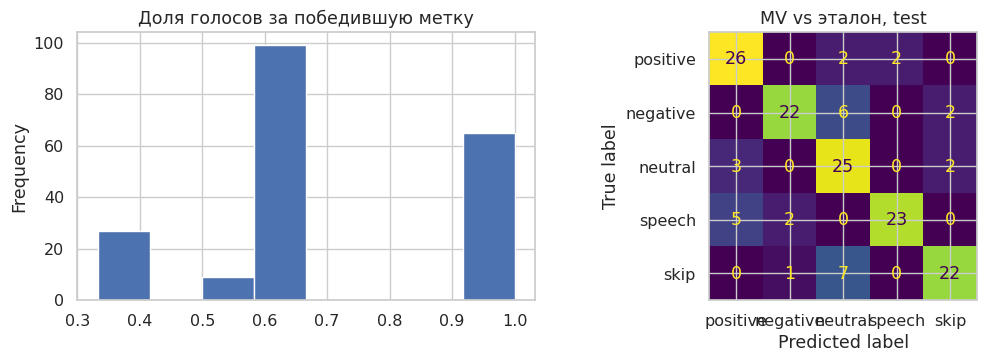

полное согласие: 0.325
слабое согласие: 0.18


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
mv["agreement"].plot(kind="hist", bins=8, ax=axes[0], title="Доля голосов за победившую метку")
ConfusionMatrixDisplay.from_predictions(
    mv_test["golden_label"], mv_test["mv_label"], labels=list(LABELS), ax=axes[1], colorbar=False
)

axes[1].set_title("MV vs эталон, test")
fig.tight_layout()
plt.show()
print("полное согласие:", float(mv["full_agreement"].mean()))
print("слабое согласие:", float(mv["weak_agreement"].mean()))


In [46]:
# Один типичный человек — среднее по исполнителям на test

single_reports = []

for performer, g in accepted[accepted["task_id"].isin(split_manifest["test"])].groupby("performer_id"):
    single_reports.append(quality_report(g["golden_label"], g["label"]))
single_acc = float(np.nanmean([r["accuracy"] for r in single_reports]))
single_f1 = float(np.nanmean([r["macro_f1"] for r in single_reports]))
n_test = len(split_manifest["test"])
log_scheme(
    "Один человек (среднее)",
    {"accuracy": single_acc, "macro_f1": single_f1},
    coverage=1.0,
    human_assignments=1,
    cost=n_test * HUMAN_COST_PER_ASSIGNMENT,
)

log_scheme(
    "Majority vote людей",
    human_mv_report,
    coverage=1.0,
    human_assignments=3,
    cost=3 * n_test * HUMAN_COST_PER_ASSIGNMENT,
)

pd.DataFrame(experiment_log).round(3)


,scheme,accuracy,macro_f1,coverage,parse_errors,human_assignments,tokens,cost,latency
0,Один человек (среднее),0.686,0.687,1.0,0.0,1,0,150.0,NaN
1,Majority vote людей,0.787,0.790,1.0,0.0,3,0,450.0,NaN


# Открытые вопросы


Открытые вопросы:


- Зачем может понадобиться такой датасет?
- Зачем использовать модели?


### Чем автоматизировать?


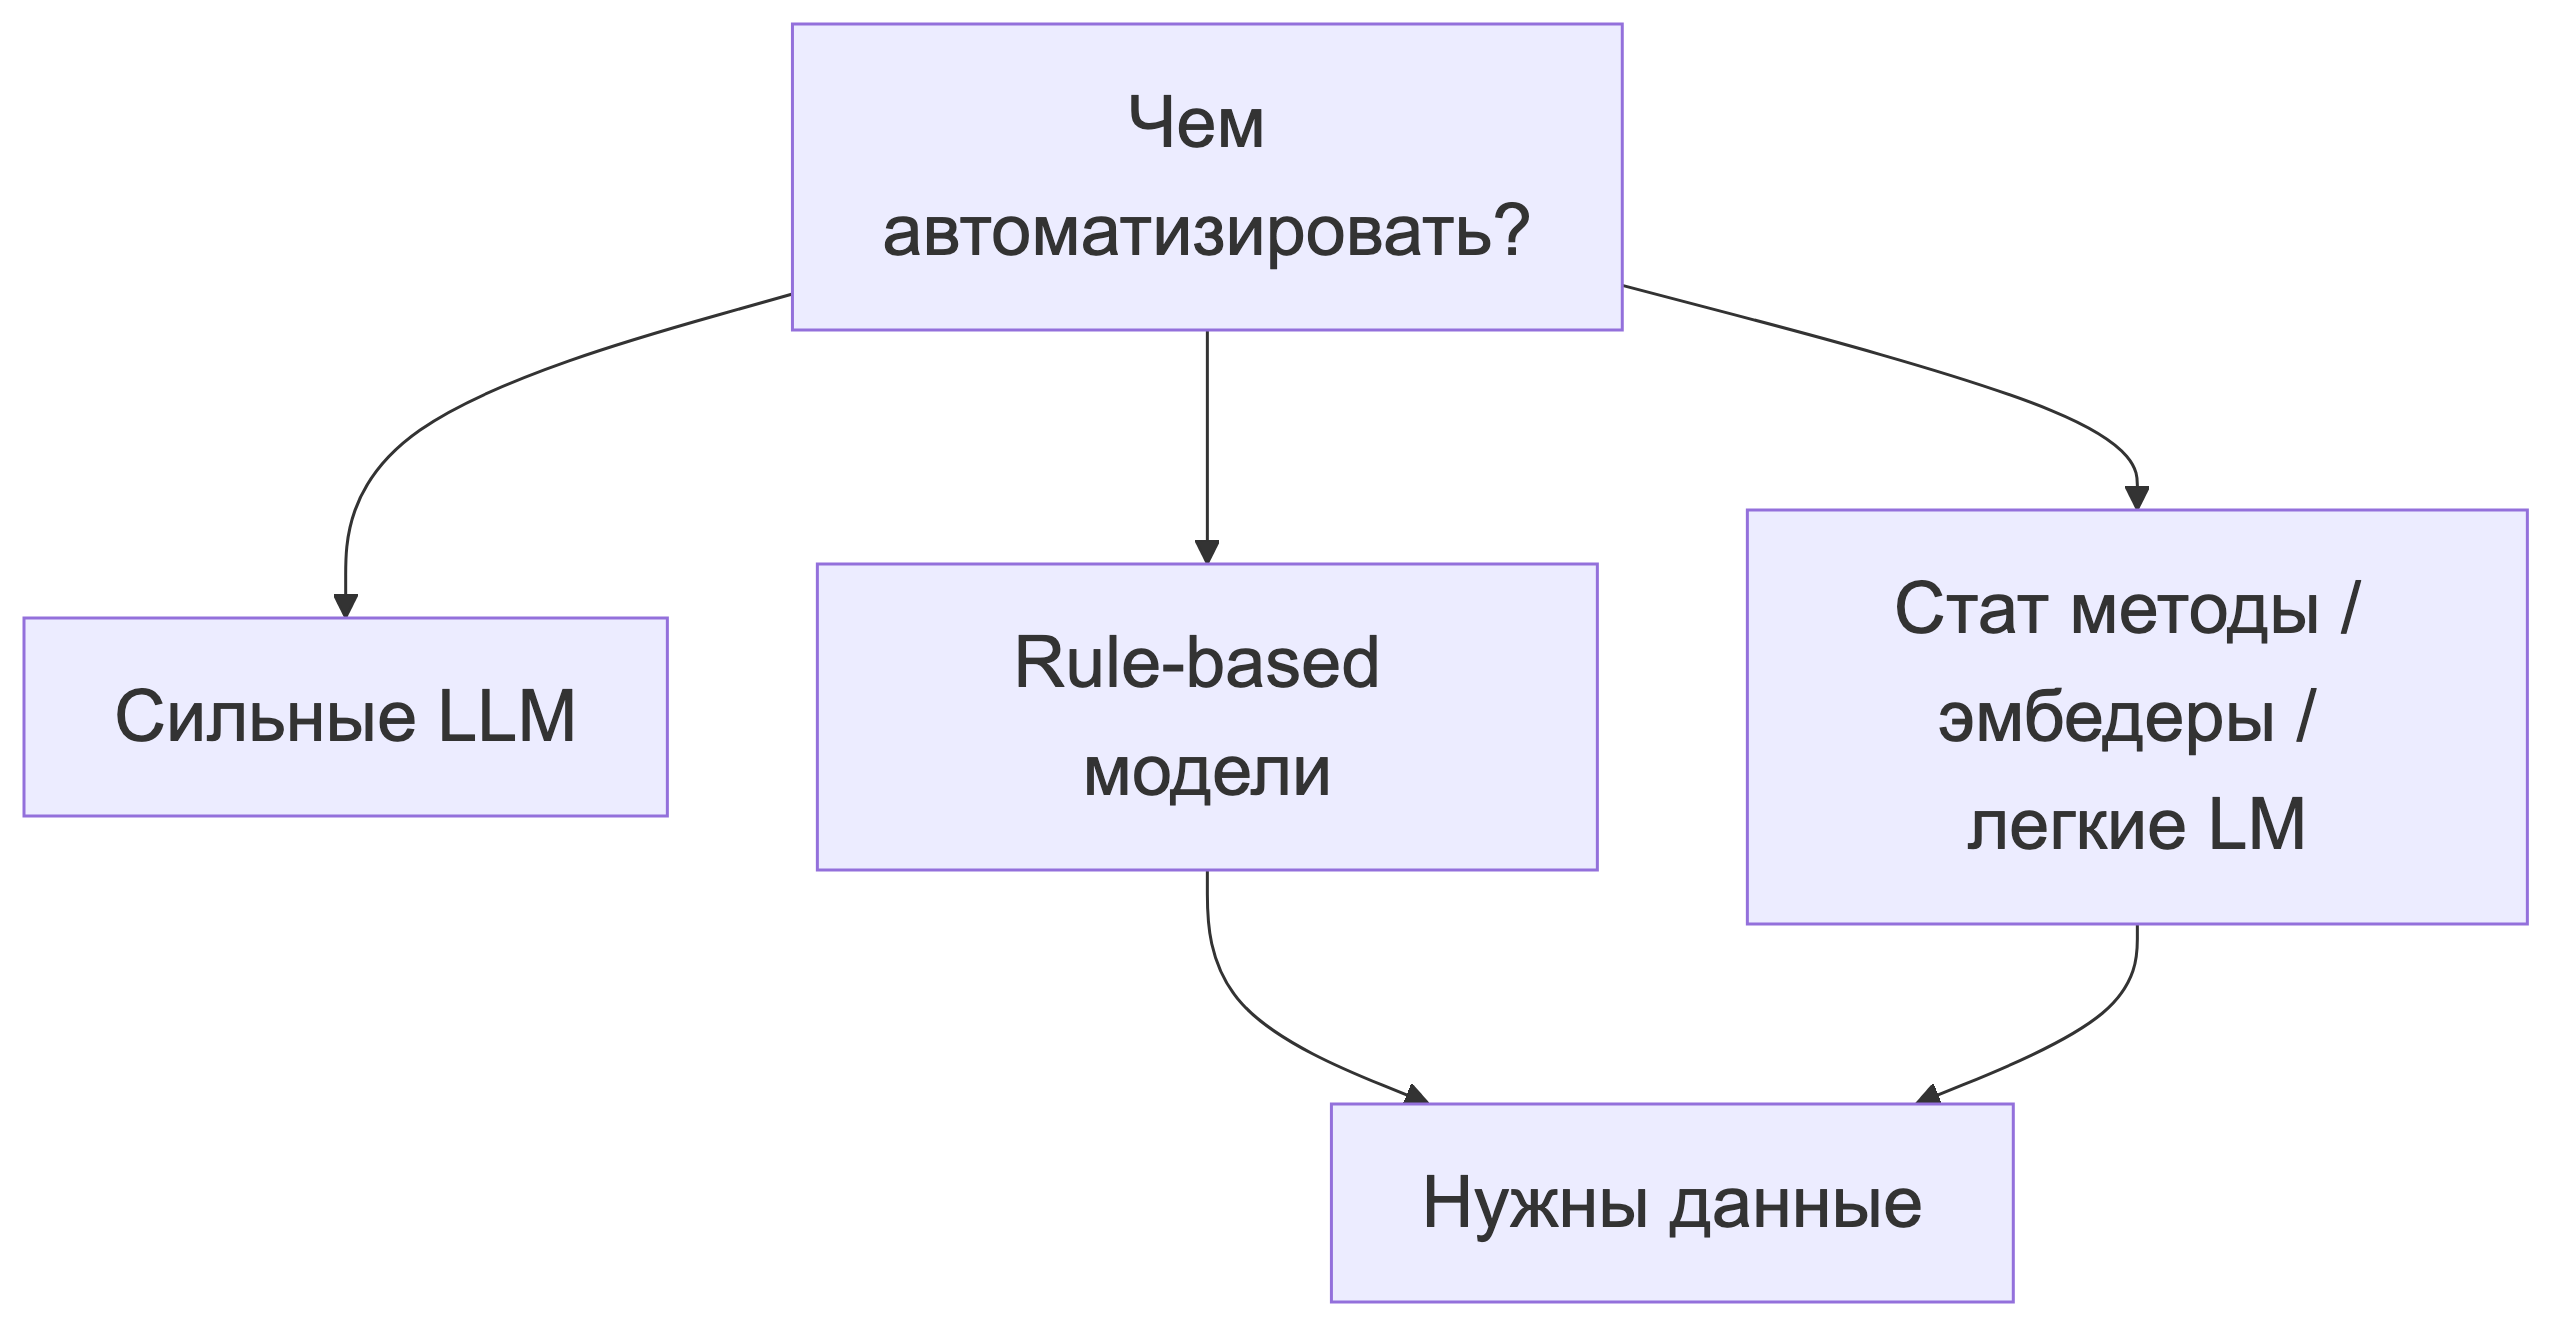

In [47]:
show_data_image("automation.png", width=720)


# Блок 3. Hugging Face и сборка промпта


Туториалы по промптингу:


- [Handbook: промптинг](https://education.yandex.ru/handbook/prompting) — Яндекс Education
- [Как писать промты для текстовых нейросетей и получить лучший результат?](https://habr.com/ru/companies/bothub/articles/930164/) — Habr, BotHub
- [Промптинг: действительно полезное руководство](https://habr.com/ru/articles/865952/) — Habr


Собираем промпт по частям: цель → задача → роль → критерии → ограничения → формат. После каждой ключевой части прогоняем **ту же** модель на нескольких тестовых примерах — так видно, как именно эта часть меняет ответ.


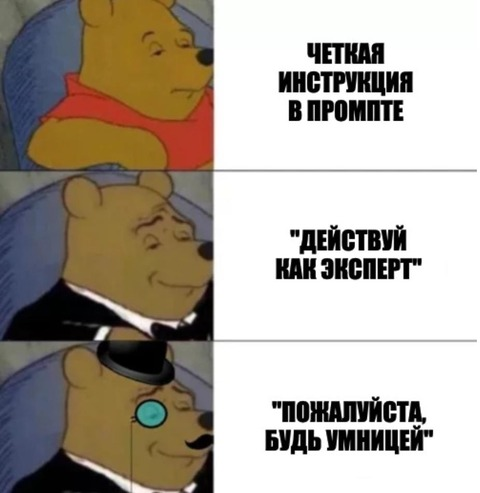

In [48]:
show_data_image("prompt_intro.jpg", width=480)


Берём три тестовых поста для быстрых сравнений и один — для ручной сборки промпта ниже.


In [49]:
demo_rows = dataset[dataset["split"] == "test"].head(3)
demo = demo_rows.iloc[0]
print("примеры для абляции:", len(demo_rows))
print()
print("task_id:", demo["task_id"])
print("эталон:", demo["golden_label"])
print("пост:")
print(demo["text"])


примеры для абляции: 3

task_id: task_bd9a1add7244
эталон: negative
пост:
Ваня я по поводу твоего хелпера на серве Ogyrochek.Достал летает по серву говорит всем о бане,пугает новичков,подозревает всех в дюпе и его хранении,мой друг играет я его пригласил дал гибридок и тут он отдавай или забаню нахер.Я построил пасику он туда залетел пчелы его покусали и он мне несет"отравление хелпера бан" . Cделай чет потомуш воще пиздец.


### Разбор ответа и бэкенд


Подключаем `parse_label` и `classify_one` — дальше ими пользуемся и в абляции промпта.


In [50]:
# Сначала пробуем JSON, потом — последнее упоминание класса в свободном тексте.
# «Последнее» важно: модель часто рассуждает вслух и только в конце ставит метку.

LABEL_PATTERNS = [
    (re.compile(r"\bpositive\b", re.I), "positive"),
    (re.compile(r"позитивн\w*|позитив", re.I), "positive"),
    (re.compile(r"\bnegative\b", re.I), "negative"),
    (re.compile(r"негативн\w*|негатив", re.I), "negative"),
    (re.compile(r"\bneutral\b|no sentiment", re.I), "neutral"),
    (re.compile(r"нейтрал\w*|без тональности", re.I), "neutral"),
    (re.compile(r"\bspeech(?:[-_ ]?act)?\b", re.I), "speech"),
    (re.compile(r"речевой(?:\s+акт)?", re.I), "speech"),
    (re.compile(r"\bskip\b", re.I), "skip"),
    (re.compile(r"пропуск\w*|пропустить", re.I), "skip"),
]


def parse_label(raw: Any) -> dict:
    """Вытащить один из пяти классов из сырого ответа модели.

    Сырую строку в метрики класть нельзя: «Вердикт: Neutral» и `{"label":"skip"}`
    должны стать `neutral` и `skip`. Если разобрать не удалось — parse_ok=False,
    это отдельная ошибка, а не ещё один класс.
    """
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return {"label": None, "parse_ok": False, "reason": "empty"}
    text = str(raw).strip()
    if not text:
        return {"label": None, "parse_ok": False, "reason": "empty"}

    fence = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, flags=re.S | re.I)
    candidate = fence.group(1) if fence else text
    brace = re.search(r"\{.*\}", candidate, flags=re.S)
    if brace:
        try:
            obj = json.loads(brace.group(0))
            value = obj.get("label") or obj.get("verdict") or obj.get("result")
            if isinstance(value, str):
                lowered = value.lower().strip()
                if lowered in LABELS:
                    return {"label": lowered, "parse_ok": True, "reason": "json"}
        except json.JSONDecodeError:
            pass  # JSON битый — пойдём искать ключевые слова

    hits = []
    for pattern, label in LABEL_PATTERNS:
        for match in pattern.finditer(text):
            hits.append((match.start(), label))
    if len(hits) == 1:
        return {"label": hits[0][1], "parse_ok": True, "reason": "keyword"}
    if len(hits) > 1:
        hits.sort()
        return {"label": hits[-1][1], "parse_ok": True, "reason": "last_keyword"}
    return {"label": None, "parse_ok": False, "reason": "unparsed"}


### Локальный вызов модели через Hugging Face


От chat-сообщений до сырого ответа: `messages` → chat template → token ids → `generate` → decode → `parse_label`.


Токенизатор можно загрузить отдельно от весов. Для семинара берём [Qwen/Qwen3-0.6B](https://huggingface.co/Qwen/Qwen3-0.6B) — она же лежит в сохранённых предсказаниях блока 4.


In [51]:
# ---------------------------------------------------------------------------
# HF: device and model loading
# ---------------------------------------------------------------------------

def resolve_hf_device() -> str:
    """cuda → mps (Apple) → cpu. Используем при загрузке и инференсе HF."""
    import torch

    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def load_hf_causal_lm(model_name: str):
    """Tokenizer + causal LM на доступном ускорителе (CUDA/MPS/CPU)."""
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    device = resolve_hf_device()
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if device == "cuda":
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype="auto",
            device_map="auto",
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype="auto")
        model = model.to(device)
    model.eval()
    print(f"HF device: {device} | model: {model_name}")
    if device == "cuda":
        print(f"  GPU: {torch.cuda.get_device_name(0)}")
    return tokenizer, model, device


In [52]:
hf_name = "Qwen/Qwen3-0.6B"
hf_tokenizer = None
hf_model = None

if RUN_LIVE_HF:
    hf_tokenizer, hf_model, hf_device = load_hf_causal_lm(hf_name)
    print("tokenizer:", type(hf_tokenizer).__name__, "| vocab:", len(hf_tokenizer))
    print("model:", hf_model.__class__.__name__, "| device:", next(hf_model.parameters()).device)
else:
    hf_device = None
    print("RUN_LIVE_HF=False — веса не грузим. Абляция покажет только текст промпта.")


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

HF device: cuda | model: Qwen/Qwen3-0.6B
  GPU: Tesla T4
tokenizer: Qwen2Tokenizer | vocab: 151669
model: Qwen3ForCausalLM | device: cuda:0


Пока без полного промпта — один пост и минимальная инструкция.


In [53]:
hf_boot_messages = [
    {
        "role": "user",
        "content": (
            f"Пост:\n{demo['text']}\n\n"
            "Ответь одной строкой: positive, negative, neutral, speech или skip."
        ),
    }
]

print(hf_boot_messages[0]["content"][:400])


Пост:
Ваня я по поводу твоего хелпера на серве Ogyrochek.Достал летает по серву говорит всем о бане,пугает новичков,подозревает всех в дюпе и его хранении,мой друг играет я его пригласил дал гибридок и тут он отдавай или забаню нахер.Я построил пасику он туда залетел пчелы его покусали и он мне несет"отравление хелпера бан" . Cделай чет потомуш воще пиздец.

Ответь одной строкой: positive, negativ


Chat template превращает список `{role, content}` в текст, который модель реально видит.


In [54]:
if hf_tokenizer is not None:
    hf_boot_prompt = hf_tokenizer.apply_chat_template(
        hf_boot_messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    print(hf_boot_prompt)
else:
    print("нет tokenizer — chat template не рендерим")


<|im_start|>user
Пост:
Ваня я по поводу твоего хелпера на серве Ogyrochek.Достал летает по серву говорит всем о бане,пугает новичков,подозревает всех в дюпе и его хранении,мой друг играет я его пригласил дал гибридок и тут он отдавай или забаню нахер.Я построил пасику он туда залетел пчелы его покусали и он мне несет"отравление хелпера бан" . Cделай чет потомуш воще пиздец.

Ответь одной строкой: positive, negative, neutral, speech или skip.<|im_end|>
<|im_start|>assistant
<think>

</think>




Дальше режем строку на id. `decode` обязан вернуть тот же текст — так проверяем, что считаем токены так же, как модель.


`convert_ids_to_tokens` показывает **внутренние BPE-кусочки** (иногда выглядят как «кракозябры») — это нормально. Важен round-trip: `decode(ids) == prompt`.


In [55]:
if hf_tokenizer is not None:
    hf_boot_ids = hf_tokenizer.encode(hf_boot_prompt)
    print("n tokens:", len(hf_boot_ids))
    print("первые id:", hf_boot_ids[:24])
    print("decode фрагмента:", repr(hf_tokenizer.decode(hf_boot_ids[:24])))
    print("round-trip ok:", hf_tokenizer.decode(hf_boot_ids) == hf_boot_prompt)
else:
    print("нет tokenizer — encode/decode пропускаем")


n tokens: 178
первые id: [151644, 872, 198, 16854, 24276, 510, 16206, 7336, 4235, 45310, 17686, 94934, 9516, 3780, 10813, 128399, 46195, 44558, 12121, 8005, 90783, 13073, 65286, 126353]
decode фрагмента: '<|im_start|>user\nПост:\nВаня я по поводу твоего хелпера на серве'
round-trip ok: True


Генерация. `classify_one("hf", ...)` делает те же шаги и сразу прогоняет ответ через `parse_label`.


In [56]:
# ---------------------------------------------------------------------------
# HF: prompt, scoring, single-call inference
# ---------------------------------------------------------------------------

def _hf_prompt_text(
    messages: list[dict],
    tokenizer,
    enable_thinking: bool = False,
) -> str:
    template_kwargs = {"tokenize": False, "add_generation_prompt": True}
    try:
        return tokenizer.apply_chat_template(
            messages, enable_thinking=enable_thinking, **template_kwargs
        )
    except TypeError:
        return tokenizer.apply_chat_template(messages, **template_kwargs)


def hf_label_probs(
    messages: list[dict],
    tokenizer,
    model,
    labels: Sequence[str] = LABELS,
    enable_thinking: bool = False,
) -> tuple[dict[str, float], dict[str, float]]:
    """Softmax log P(label | prompt): forced-choice scoring по пяти меткам."""
    import torch
    import torch.nn.functional as F

    prompt = _hf_prompt_text(messages, tokenizer, enable_thinking=enable_thinking)
    device = getattr(model, "device", None)
    if device is None or str(device) == "meta":
        device = next(model.parameters()).device

    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)
    logps: dict[str, float] = {}
    for label in labels:
        best = float("-inf")
        for variant in (label, f" {label}"):
            label_ids = tokenizer.encode(variant, add_special_tokens=False)
            if not label_ids:
                continue
            input_ids = prompt_ids + label_ids
            inp = torch.tensor([input_ids], device=device)
            with torch.no_grad():
                logits = model(inp).logits
            lp = F.log_softmax(logits[0], dim=-1)
            total = 0.0
            start = len(prompt_ids)
            for j, token_id in enumerate(label_ids):
                pos = start - 1 + j
                total += lp[pos, token_id].item()
            best = max(best, total)
        logps[label] = best

    arr = np.array([logps[label] for label in labels], dtype=float)
    arr = arr - arr.max()
    probs_arr = np.exp(arr)
    probs_arr = probs_arr / probs_arr.sum()
    probs = {label: float(probs_arr[i]) for i, label in enumerate(labels)}
    return probs, logps


def classify_one_hf(
    messages: list[dict],
    tokenizer,
    model,
    max_new_tokens: int = 32,
    temperature: float = 0.0,
    enable_thinking: bool = False,
) -> dict:
    """Локальный вызов HF. Метка — из generate+parse; confidence — из logprobs по LABELS."""
    import torch

    t0 = time.perf_counter()
    prompt = _hf_prompt_text(messages, tokenizer, enable_thinking=enable_thinking)

    if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
        tokenizer.pad_token = tokenizer.eos_token

    device = getattr(model, "device", None)
    if device is None or str(device) == "meta":
        device = next(model.parameters()).device
    inputs = tokenizer([prompt], return_tensors="pt")
    inputs = {key: value.to(device) for key, value in inputs.items()}

    gen_kwargs: dict[str, Any] = {
        "max_new_tokens": max_new_tokens,
        "do_sample": temperature > 0,
        "pad_token_id": tokenizer.pad_token_id,
    }
    if temperature > 0:
        gen_kwargs["temperature"] = temperature

    with torch.no_grad():
        output_ids = model.generate(**inputs, **gen_kwargs)
    n_in = int(inputs["input_ids"].shape[1])
    generated = output_ids[0][n_in:]  # отрезаем сам промпт, оставляем ответ
    raw = tokenizer.decode(generated, skip_special_tokens=True).strip()
    parsed = parse_label(raw)

    label_probs, label_logprobs = hf_label_probs(
        messages, tokenizer, model, enable_thinking=enable_thinking
    )
    ordered = sorted(label_probs.values(), reverse=True)
    margin = float(ordered[0] - ordered[1]) if len(ordered) > 1 else float(ordered[0])
    label = parsed["label"]
    if label in label_probs:
        confidence = float(label_probs[label])
    else:
        confidence = float(ordered[0]) * (0.5 if not parsed["parse_ok"] else 0.75)

    latency = time.perf_counter() - t0
    return {
        "raw": raw,
        "label": label,
        "parse_ok": parsed["parse_ok"],
        "parse_reason": parsed["reason"],
        "confidence": confidence,
        "margin": margin,
        "label_probs": label_probs,
        "label_logprobs": label_logprobs,
        "confidence_source": "hf_logprobs",
        "latency_sec": latency,
        "n_input_tokens": n_in,
        "n_output_tokens": int(generated.shape[0]),
        "model": getattr(model, "name_or_path", "hf"),
        "backend": "hf",
    }


def classify_one(backend: str, messages: list[dict], **kwargs) -> dict:
    """Единая точка входа: backend='hf' (основной) или 'openrouter' (демо)."""
    if backend == "hf":
        return classify_one_hf(messages, **kwargs)
    if backend == "openrouter":
        return classify_one_openrouter(messages, **kwargs)
    raise ValueError(f"Unknown backend {backend}")


In [57]:
hf_boot = None

if RUN_LIVE_HF:
    hf_boot = classify_one(
        "hf",
        hf_boot_messages,
        tokenizer=hf_tokenizer,
        model=hf_model,
        max_new_tokens=32,
        temperature=0.0,
        enable_thinking=False,
    )
    show = {k: hf_boot[k] for k in hf_boot if k not in {"raw", "label_logprobs", "label_probs"}}
    print(show)
    print("raw:", hf_boot["raw"][:300])
    print("label_probs:", {k: round(v, 3) for k, v in hf_boot["label_probs"].items()})
else:
    print("RUN_LIVE_HF=False — пример разбора на заготовленном ответе:")
    print(parse_label('{"label":"neutral"}'))


{'label': 'positive', 'parse_ok': True, 'parse_reason': 'keyword', 'confidence': 0.6906314334403937, 'margin': 0.4032951712873901, 'confidence_source': 'hf_logprobs', 'latency_sec': 2.251751688000013, 'n_input_tokens': 178, 'n_output_tokens': 2, 'model': 'Qwen/Qwen3-0.6B', 'backend': 'hf'}
raw: positive
label_probs: {'positive': 0.691, 'negative': 0.021, 'neutral': 0.001, 'speech': 0.287, 'skip': 0.0}


### Сборка промпта по частям


Теперь собираем промпт и после каждой ключевой части вызываем ту же HF-модель на трёх постах.


In [58]:
FMT_ONE_LINE = "Ответь одной строкой: positive, negative, neutral, speech или skip."
GOAL = "Цель: разметить тональность поста ВК."


def run_prompt_ablation(name, *, system=None, user_parts, rows=None):
    """Прогнать текущий кусок промпта на нескольких постах и сразу показать таблицу."""
    rows = demo_rows if rows is None else rows
    print(f"--- {name} ---")
    if system:
        print("system:", system)
    print("user blocks:", user_parts)
    if not RUN_LIVE_HF or hf_model is None:
        sample_user = "\n\n".join([*user_parts, f"Пост:\n{rows.iloc[0]['text']}", FMT_ONE_LINE])
        print("RUN_LIVE_HF=False — показываем промпт для первого примера:")
        print(sample_user[:700])
        if len(sample_user) > 700:
            print("...")
        return None

    records = []
    for _, row in rows.iterrows():
        user = "\n\n".join([*user_parts, f"Пост:\n{row['text']}", FMT_ONE_LINE])
        messages = []
        if system:
            messages.append({"role": "system", "content": system})
        messages.append({"role": "user", "content": user})
        rec = classify_one(
            "hf",
            messages,
            tokenizer=hf_tokenizer,
            model=hf_model,
            max_new_tokens=32,
            temperature=0.0,
            enable_thinking=False,
        )
        records.append(
            {
                "variant": name,
                "task_id": row["task_id"],
                "golden": row["golden_label"],
                "label": rec["label"],
                "parse_ok": rec["parse_ok"],
                "raw": rec["raw"][:120],
            }
        )
    df = pd.DataFrame(records)
    display(df[["golden", "label", "parse_ok", "raw"]])
    return df


### Цель


Какой финальный результат мы ждём от промпта?


In [59]:
prompt_parts = [GOAL]
print(prompt_parts[-1])
run_prompt_ablation("только цель", user_parts=[GOAL])


Цель: разметить тональность поста ВК.
--- только цель ---
user blocks: ['Цель: разметить тональность поста ВК.']


,golden,label,parse_ok,raw
0,negative,positive,True,positive
1,skip,positive,True,positive
2,skip,positive,True,positive


,variant,task_id,golden,label,parse_ok,raw
0,только цель,task_bd9a1add7244,negative,positive,True,positive
1,только цель,task_c7a9d4f45748,skip,positive,True,positive
2,только цель,task_6d706b9b2ddf,skip,positive,True,positive


### Задача


Одну метку из фиксированного списка, не пересказ.


In [60]:
TASK = "Задача: поставить ровно одну метку: positive, negative, neutral, speech или skip."
prompt_parts.append(TASK)
print("\n".join(prompt_parts))


Цель: разметить тональность поста ВК.
Задача: поставить ровно одну метку: positive, negative, neutral, speech или skip.


### Роль


Кто отвечает: разметчик по схеме RuSentiment, не болтливый ассистент.


Прогоняем **только роль + цель** — без критериев и без задачи, чтобы увидеть эффект роли отдельно.


In [61]:
role = (
    "Ты разметчик тональности постов ВКонтакте по схеме RuSentiment. "
    "Поставь ровно одну метку: positive, negative, neutral, speech или skip. "
    "Не добавляй вежливых предисловий."
)

print(role)
run_prompt_ablation("роль + цель", system=role, user_parts=[GOAL])


Ты разметчик тональности постов ВКонтакте по схеме RuSentiment. Поставь ровно одну метку: positive, negative, neutral, speech или skip. Не добавляй вежливых предисловий.
--- роль + цель ---
system: Ты разметчик тональности постов ВКонтакте по схеме RuSentiment. Поставь ровно одну метку: positive, negative, neutral, speech или skip. Не добавляй вежливых предисловий.
user blocks: ['Цель: разметить тональность поста ВК.']


,golden,label,parse_ok,raw
0,negative,positive,True,positive
1,skip,positive,True,positive
2,skip,positive,True,positive


,variant,task_id,golden,label,parse_ok,raw
0,роль + цель,task_bd9a1add7244,negative,positive,True,positive
1,роль + цель,task_c7a9d4f45748,skip,positive,True,positive
2,роль + цель,task_6d706b9b2ddf,skip,positive,True,positive


### Критерии


Те же правила, что у людей в инструкции. Сначала фрагмент инструкции, потом компактная версия для промпта.


Прогоняем **только цель + критерии** — без роли в system, чтобы сравнить с предыдущим шагом.


In [62]:
print(public_instructions[:900])


<p>Вам показывают посты из социальной сети ВКонтакте. Нужно поставить <b>ровно одну</b> метку тональности по схеме RuSentiment.</p>
<p>Метки: <code>positive</code>, <code>negative</code>, <code>neutral</code>, <code>speech</code>, <code>skip</code>.</p>
<p>Размечаем <b>доминирующую тональность поста целиком</b>, а не отдельных фраз. Смешанные случаи — по преобладающему чувству. Если сомневаетесь — <code>skip</code>.</p>

<h2>positive</h2>
<p>Явная или подразумеваемая позитивная оценка, настроение или отношение. Сюда относятся и желание / рекомендация («хочу снега», «обязательно попробуй»).</p>
<p>Примеры:</p>
<ul>
<li><i>УРРРРААААААА!!!!!! )))</i></li>
<li><i>годный дабстеп, очень годный.</i></li>
<li><i>мы победили!</i></li>
<li><i>Еду во Францию ))</i></li>
</ul>

<h2>negative</h2>
<p>Явная или подразумеваемая негативная оценка, настроение или отношение. Сарказм, когда «хорошими» слова


In [63]:
# ---------------------------------------------------------------------------
# Prompts
# ---------------------------------------------------------------------------

CRITERIA_RU = """
Классы RuSentiment (ровно одна метка):

positive — явная или подразумеваемая позитивная оценка, настроение или отношение.
Желание / рекомендация («хочу», «обязательно попробуй») — тоже positive.

negative — явная или подразумеваемая негативная оценка или настроение.
Сарказм, когда хорошими словами описывают плохое, — negative.

speech — речевой акт: поздравление, благодарность, приветствие, пожелание.
Даже «позитивная» формула вежливости — speech, не positive.

neutral — факт, обычный вопрос, реклама, описание без тональности.
Смайлик сам по себе не делает пост тональным.

skip — неясно без контекста, не русский язык, шутка, смешанный неразборчивый случай.
Если сомневаетесь — skip.

Размечайте доминирующую тональность поста целиком. Хештеги — как обычные слова.
""".strip()  # те же правила, что у людей в instruction.html


In [64]:
prompt_parts.append("Критерии:\n" + CRITERIA_RU)
print(CRITERIA_RU)
run_prompt_ablation(
    "цель + критерии",
    user_parts=[GOAL, "Критерии:\n" + CRITERIA_RU],
)


Классы RuSentiment (ровно одна метка):

positive — явная или подразумеваемая позитивная оценка, настроение или отношение.
Желание / рекомендация («хочу», «обязательно попробуй») — тоже positive.

negative — явная или подразумеваемая негативная оценка или настроение.
Сарказм, когда хорошими словами описывают плохое, — negative.

speech — речевой акт: поздравление, благодарность, приветствие, пожелание.
Даже «позитивная» формула вежливости — speech, не positive.

neutral — факт, обычный вопрос, реклама, описание без тональности.
Смайлик сам по себе не делает пост тональным.

skip — неясно без контекста, не русский язык, шутка, смешанный неразборчивый случай.
Если сомневаетесь — skip.

Размечайте доминирующую тональность поста целиком. Хештеги — как обычные слова.
--- цель + критерии ---
user blocks: ['Цель: разметить тональность поста ВК.', 'Критерии:\nКлассы RuSentiment (ровно одна метка):\n\npositive — явная или подразумеваемая позитивная оценка, настроение или отношение.\nЖелание / ре

,golden,label,parse_ok,raw
0,negative,positive,True,positive
1,skip,positive,True,positive
2,skip,positive,True,positive


,variant,task_id,golden,label,parse_ok,raw
0,цель + критерии,task_bd9a1add7244,negative,positive,True,positive
1,цель + критерии,task_c7a9d4f45748,skip,positive,True,positive
2,цель + критерии,task_6d706b9b2ddf,skip,positive,True,positive


### Ограничения


In [65]:
prompt_parts.append("Ограничения: не пересказывай пост, не ставь другие метки, не выдумывай контекст.")
print(prompt_parts[-1])


Ограничения: не пересказывай пост, не ставь другие метки, не выдумывай контекст.


### Формат


In [66]:
fmt_zero = FMT_ONE_LINE
prompt_parts.append(fmt_zero)
print(fmt_zero)


Ответь одной строкой: positive, negative, neutral, speech или skip.


### Объект


Сам пост — всегда последним, чтобы модель не потеряла, что именно размечать.


In [67]:
prompt_parts.append("Пост:\n" + demo["text"])
print(prompt_parts[-1])


Пост:
Ваня я по поводу твоего хелпера на серве Ogyrochek.Достал летает по серву говорит всем о бане,пугает новичков,подозревает всех в дюпе и его хранении,мой друг играет я его пригласил дал гибридок и тут он отдавай или забаню нахер.Я построил пасику он туда залетел пчелы его покусали и он мне несет"отравление хелпера бан" . Cделай чет потомуш воще пиздец.


### Собираем


In [68]:
print("--- system ---")
print(role)
print()
print("--- user ---")
print("\n\n".join(prompt_parts))


--- system ---
Ты разметчик тональности постов ВКонтакте по схеме RuSentiment. Поставь ровно одну метку: positive, negative, neutral, speech или skip. Не добавляй вежливых предисловий.

--- user ---
Цель: разметить тональность поста ВК.

Задача: поставить ровно одну метку: positive, negative, neutral, speech или skip.

Критерии:
Классы RuSentiment (ровно одна метка):

positive — явная или подразумеваемая позитивная оценка, настроение или отношение.
Желание / рекомендация («хочу», «обязательно попробуй») — тоже positive.

negative — явная или подразумеваемая негативная оценка или настроение.
Сарказм, когда хорошими словами описывают плохое, — negative.

speech — речевой акт: поздравление, благодарность, приветствие, пожелание.
Даже «позитивная» формула вежливости — speech, не positive.

neutral — факт, обычный вопрос, реклама, описание без тональности.
Смайлик сам по себе не делает пост тональным.

skip — неясно без контекста, не русский язык, шутка, смешанный неразборчивый случай.
Если

In [69]:
messages_zero = [
    {"role": "system", "content": role},
    {"role": "user", "content": "\n\n".join(prompt_parts)},
]

print("сообщений:", len(messages_zero))
print("роли:", [m["role"] for m in messages_zero])


сообщений: 2
роли: ['system', 'user']


Четыре конфигурации отличаются только хвостом: примерами и форматом ответа. Каркас тот же.


In [70]:
fmt_reasoning = (
    "Сначала мысленно проверь критерии по пунктам. "
    "В ответе не пиши рассуждение. Последняя строка должна быть "
    "positive, negative, neutral, speech или skip."
)

fmt_structured = (
    'Ответь строго JSON-объектом вида {"label": "positive"} '
    "(label — одна из: positive, negative, neutral, speech, skip) без других ключей."
)

print("reasoning:\n", fmt_reasoning, "\n")
print("structured:\n", fmt_structured)


reasoning:
 Сначала мысленно проверь критерии по пунктам. В ответе не пиши рассуждение. Последняя строка должна быть positive, negative, neutral, speech или skip. 

structured:
 Ответь строго JSON-объектом вида {"label": "positive"} (label — одна из: positive, negative, neutral, speech, skip) без других ключей.


Эта сборка понадобится много раз — оборачиваем в функцию. `mode` меняет только формат и few-shot примеры.


In [71]:
def _row_get(row: pd.Series | dict, key: str, default: str = "") -> str:
    """Достать поле и из Series, и из dict — batch-инференс ходит обоими путями."""
    if isinstance(row, dict):
        value = row.get(key, default)
    else:
        value = row[key] if key in row.index else default
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return default
    return str(value)


def build_prompt(
    row: pd.Series | dict,
    mode: str = "zero_shot",
    examples: pd.DataFrame | None = None,
) -> list[dict]:
    """Собрать chat-сообщения. Каркас один, меняется только формат ответа и примеры.

    mode:
      zero_shot  — инструкция, без примеров
      few_shot   — те же критерии + примеры из split=prompt_examples
      reasoning  — «проверь критерии», но в ответ просим только метку
      structured — просим JSON {"label": "..."}
    """
    text = _row_get(row, "text")

    system = (
        "Ты разметчик тональности постов ВКонтакте по схеме RuSentiment. "
        "Поставь ровно одну метку: positive, negative, neutral, speech или skip. "
        "Не добавляй вежливых предисловий."
    )
    task = (
        "Цель: разметить тональность поста ВК.\n"
        f"Критерии:\n{CRITERIA_RU}\n"
        "Ограничения: не пересказывай пост, не ставь другие метки, не выдумывай контекст."
    )

    labels_line = "positive, negative, neutral, speech или skip"
    if mode == "zero_shot":
        fmt = f"Ответь одной строкой: {labels_line}."
    elif mode == "few_shot":
        fmt = f"Ответь одной строкой: {labels_line}."
    elif mode == "reasoning":
        fmt = (
            "Сначала мысленно проверь критерии по пунктам. "
            f"В ответе не пиши рассуждение. Последняя строка должна быть {labels_line}."
        )
    elif mode == "structured":
        fmt = (
            'Ответь строго JSON-объектом вида {"label": "positive"} '
            "(label — одна из: positive, negative, neutral, speech, skip) без других ключей."
        )
    else:
        raise ValueError(mode)

    user_parts = [task, fmt]
    if mode == "few_shot" and examples is not None and len(examples):
        shots = []
        for ex in examples.itertuples(index=False):
            shots.append(f"Пост:\n{ex.text}\nОтвет: {ex.golden_label}")
        user_parts.append("Примеры:\n\n" + "\n\n".join(shots))

    user_parts.append(f"Пост:\n{text}")  # сам объект — всегда последним
    return [
        {"role": "system", "content": system},
        {"role": "user", "content": "\n\n".join(user_parts)},
    ]


In [72]:
built = build_prompt(demo, mode="zero_shot")
print(built[1]["content"][:700])
print("...")
print("совпадает с ручной сборкой:", built[0]["content"] == role)


Цель: разметить тональность поста ВК.
Критерии:
Классы RuSentiment (ровно одна метка):

positive — явная или подразумеваемая позитивная оценка, настроение или отношение.
Желание / рекомендация («хочу», «обязательно попробуй») — тоже positive.

negative — явная или подразумеваемая негативная оценка или настроение.
Сарказм, когда хорошими словами описывают плохое, — negative.

speech — речевой акт: поздравление, благодарность, приветствие, пожелание.
Даже «позитивная» формула вежливости — speech, не positive.

neutral — факт, обычный вопрос, реклама, описание без тональности.
Смайлик сам по себе не делает пост тональным.

skip — неясно без контекста, не русский язык, шутка, смешанный неразборч
...
совпадает с ручной сборкой: True


### Разбор ответа


Модель отвечает как хочет. Нужно привести сырую строку к одному из пяти классов. Смотрим по одному примеру — функция `parse_label` уже подключена выше.


In [73]:
print(parse_label("positive"))


{'label': 'positive', 'parse_ok': True, 'reason': 'keyword'}


In [74]:
print(parse_label('{"label": "skip"}'))


{'label': 'skip', 'parse_ok': True, 'reason': 'json'}


In [75]:
print(parse_label("Вердикт: Neutral\n"))
print(parse_label("не знаю"))
print(parse_label('```json\n{"verdict":"speech"}\n```'))
print(parse_label("Ответ: негативный"))


{'label': 'neutral', 'parse_ok': True, 'reason': 'keyword'}
{'label': None, 'parse_ok': False, 'reason': 'unparsed'}
{'label': 'speech', 'parse_ok': True, 'reason': 'json'}
{'label': 'negative', 'parse_ok': True, 'reason': 'keyword'}


Полный промпт — ещё один вызов той же HF-модели на одном посте. Массовый прогон уже лежит в parquet.


In [76]:
hf_full = None

if RUN_LIVE_HF:
    if hf_tokenizer is not None:
        hf_full_prompt = hf_tokenizer.apply_chat_template(
            messages_zero,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )
        print("полный prompt, первые 700 символов:")
        print(hf_full_prompt[:700])
        print("...")
    hf_full = classify_one(
        "hf",
        messages_zero,
        tokenizer=hf_tokenizer,
        model=hf_model,
        max_new_tokens=32,
        temperature=0.0,
        enable_thinking=False,
    )
    print({k: hf_full[k] for k in hf_full if k != "raw"})
    print("raw:", hf_full["raw"][:300])
else:
    print("RUN_LIVE_HF=False — полный инференс возьмём из model_predictions.parquet в блоке 4.")
    print("пример разбора, как если бы модель ответила так:")
    print(parse_label('{"label":"skip"}'))


полный prompt, первые 700 символов:
<|im_start|>system
Ты разметчик тональности постов ВКонтакте по схеме RuSentiment. Поставь ровно одну метку: positive, negative, neutral, speech или skip. Не добавляй вежливых предисловий.<|im_end|>
<|im_start|>user
Цель: разметить тональность поста ВК.

Задача: поставить ровно одну метку: positive, negative, neutral, speech или skip.

Критерии:
Классы RuSentiment (ровно одна метка):

positive — явная или подразумеваемая позитивная оценка, настроение или отношение.
Желание / рекомендация («хочу», «обязательно попробуй») — тоже positive.

negative — явная или подразумеваемая негативная оценка или настроение.
Сарказм, когда хорошими словами описывают плохое, — negative.

speech — речевой акт: 
...
{'label': 'positive', 'parse_ok': True, 'parse_reason': 'keyword', 'confidence': 0.6204515367927861, 'margin': 0.28769848684467264, 'label_probs': {'positive': 0.6204515367927861, 'negative': 0.027101474150885586, 'neutral': 0.0010673864848803984, 'speech': 0

### Уверенность для HF


Для `backend='hf'` `confidence_heuristic` берёт **softmax log P(label | prompt)** по пяти меткам (`hf_label_probs`): после chat template для каждого класса считаем logprob токенов ответа и нормируем.


`confidence` = вероятность **распарсенной** метки; `margin` = разрыв top-1 и top-2. Если `parse_label` не нашёл класс — confidence занижается.


В сохранённых parquet без logprobs остаётся запасная эвристика по `parse_reason` (0.90 / 0.80 / 0.62 / 0.42).


### Опционально: один вызов через OpenRouter API


На семинаре массовый инференс идёт только через HF. Ниже — минимальный пример HTTP-вызова тем же промптом, если есть ключ в `.env`.


In [77]:
# ---------------------------------------------------------------------------
# OpenRouter: один HTTP-вызов (демо, не массовый инференс)
# ---------------------------------------------------------------------------

def _openrouter_message_text(msg: dict) -> str:
    """Достать текст ответа: content может быть пустым, если модель потратила токены на reasoning."""
    content = msg.get("content")
    if isinstance(content, str) and content.strip():
        return content
    if isinstance(content, list):
        parts = []
        for part in content:
            if isinstance(part, str):
                parts.append(part)
            elif isinstance(part, dict):
                parts.append(str(part.get("text") or part.get("content") or ""))
        joined = "".join(parts).strip()
        if joined:
            return joined
    for key in ("reasoning", "reasoning_content"):
        value = msg.get(key)
        if isinstance(value, str) and value.strip():
            return value
    return "" if content is None else str(content)


def classify_one_openrouter(
    messages: list[dict],
    model: str,
    temperature: float = 0.0,
    max_tokens: int = 64,
    timeout: int = 60,
    response_format: dict | None = None,
    extra_body: dict | None = None,
) -> dict:
    """Один вызов OpenRouter. temperature=0 — меньше случайности, проще сравнивать промпты."""
    api_key = os.environ.get("OPENROUTER_API_KEY")
    if not api_key:
        raise RuntimeError("OPENROUTER_API_KEY is not set")
    payload: dict[str, Any] = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "max_tokens": max_tokens,
    }
    if response_format is not None:
        payload["response_format"] = response_format
    if extra_body:
        payload.update(extra_body)
    t0 = time.perf_counter()
    import requests

    response = requests.post(
        "https://openrouter.ai/api/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json",
        },
        json=payload,
        timeout=timeout,
    )
    latency = time.perf_counter() - t0
    if not response.ok:
        raise RuntimeError(f"OpenRouter HTTP {response.status_code}: {response.text[:500]}")
    body = response.json()
    choice = _openrouter_message_text(body["choices"][0]["message"])
    usage = body.get("usage") or {}
    parsed = parse_label(choice)
    return {
        "raw": choice,
        "label": parsed["label"],
        "parse_ok": parsed["parse_ok"],
        "parse_reason": parsed["reason"],
        "latency_sec": latency,
        "n_input_tokens": usage.get("prompt_tokens"),
        "n_output_tokens": usage.get("completion_tokens"),
        "model": model,
        "backend": "openrouter",
    }


In [78]:
if os.environ.get("OPENROUTER_API_KEY"):
    try:
        or_demo = classify_one_openrouter(
            hf_boot_messages,
            model=os.environ.get("OPENROUTER_MODEL", "openai/gpt-4o-mini"),
            temperature=0.0,
            max_tokens=32,
        )
        print({k: or_demo[k] for k in or_demo if k != "raw"})
        print("raw:", or_demo["raw"][:200])
    except Exception as exc:
        print("OpenRouter demo не выполнен:", type(exc).__name__, str(exc)[:200])
else:
    print("OPENROUTER_API_KEY не задан — пропускаем демо OpenRouter")


OPENROUTER_API_KEY не задан — пропускаем демо OpenRouter


### Дальше: автоматическая оптимизация промпта


Из [CROWDYAGPT-4517](https://st.yandex-team.ru/CROWDYAGPT-4517) и дополнительных первичных источников — пять работ, максимально близких к циклу `diagnose → rewrite → evaluate → select`:


1. [SAGE: Stochastic Prompt Optimization via Agent-Guided Exploration](https://arxiv.org/abs/2606.18902) — агент анализирует ошибки, запускает диагностический код, генерирует изменения и принимает их по количественной проверке.
2. [SPEAR: Code-Augmented Agentic Prompt Optimization](https://arxiv.org/abs/2605.26275) — автономный prompt-agent с инструментами `evaluate`, `python`, `set_prompt`, `finish`; есть rollback при регрессии и guard-метрики.
3. [SePO: Self-Evolving Prompt Agent for System Prompt Optimization](https://arxiv.org/abs/2606.04465) — агент эволюционно улучшает одновременно целевой system prompt и собственный meta-prompt, сохраняя архив кандидатов.
4. [From Monolithic to Modular: Segment-level Automatic Prompt Optimization](https://arxiv.org/abs/2608.11219) — промпт разбивается на `role/context/task/output format`; агент диагностирует слабые сегменты и меняет их изолированно.
5. [Prompt Codebooks](https://arxiv.org/abs/2605.28360) — генератор собирает промпт из атомарных правил; critic выдаёт структурированный feedback, который обновляет генератор, router и библиотеку правил.


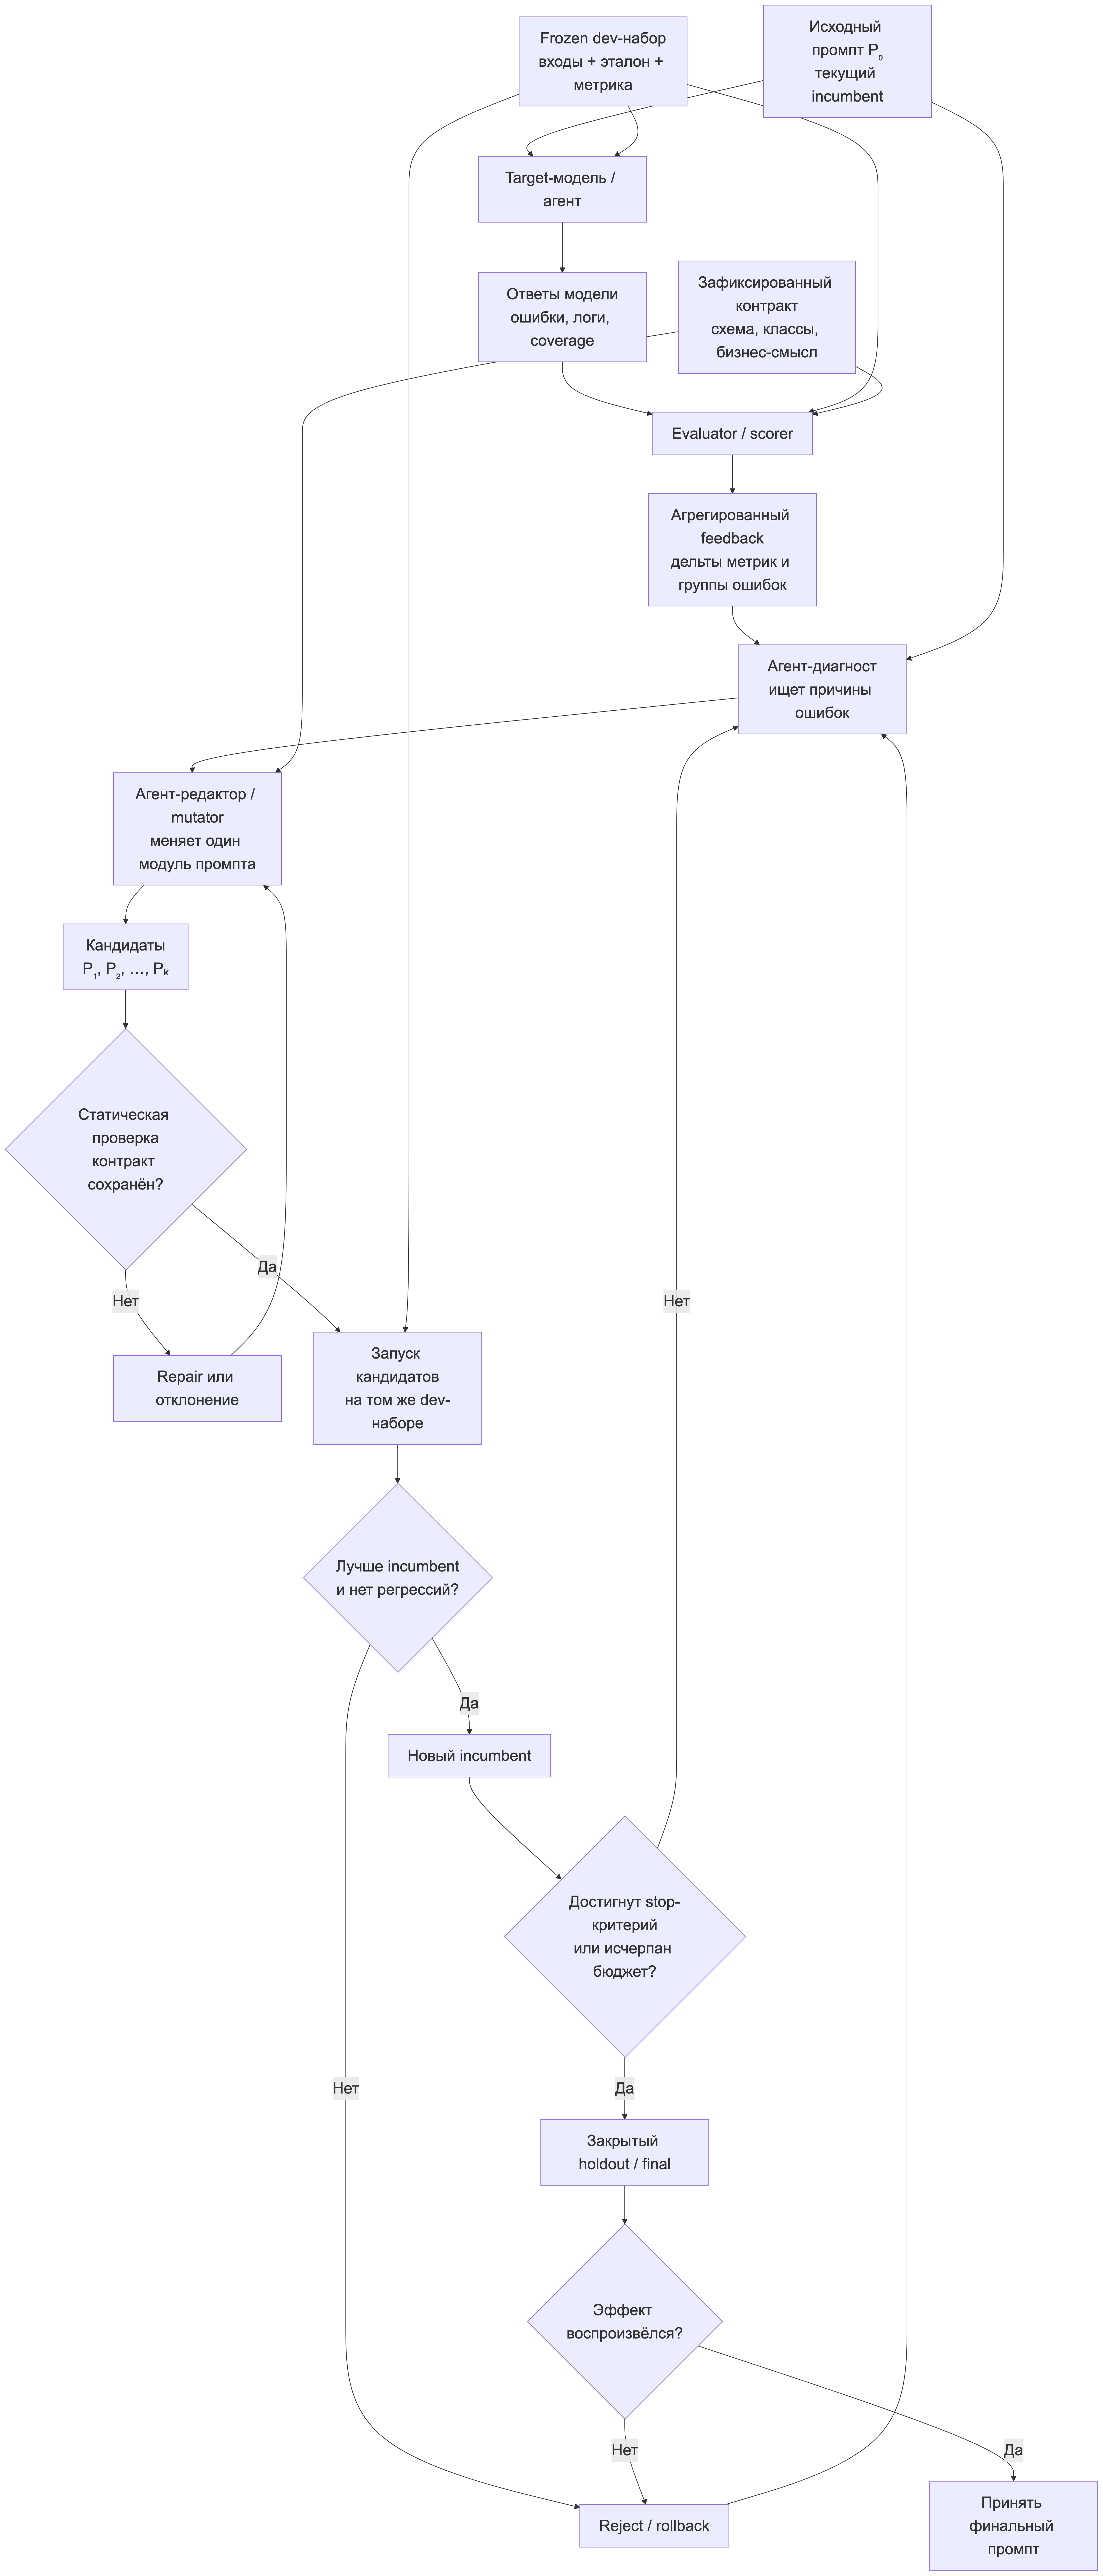

In [79]:
show_data_image("prompt_optimizer.png", width=900)


# Блок 4. Prompt ladder и модель в контуре разметки


Сравниваем четыре конфигурации на одних и тех же `task_id`.


- **`RUN_LIVE_HF=True`** — `batch_hf_inference` по `calibration` + `test` (модель из блока 3).
- **`RUN_LIVE_HF=True` и `RUN_REBUILD_ARTIFACTS=True`** — то же + сохраняем `model_predictions.parquet` и `call_log`.
- **`RUN_LIVE_HF=False`** — читаем готовый `model_predictions.parquet`.


Для отладки: `HF_MAX_ROWS=20` в окружении.


In [80]:
# ---------------------------------------------------------------------------
# Unified row-level inference (same code in notebook and offline scripts)
# ---------------------------------------------------------------------------

def classify_one_unified(
    row: pd.Series | dict,
    mode: str = "structured",
    backend: str = "hf",
    examples: pd.DataFrame | None = None,
    **kwargs,
) -> dict:
    """Одна строка датасета → метка. Backend и формат промпта — параметры."""
    messages = build_prompt(row, mode=mode, examples=examples)
    return classify_one(backend, messages, **kwargs)


def confidence_heuristic(rec: dict) -> tuple[float, float, dict[str, float]]:
    """Уверенность для pick_threshold: HF — softmax logprobs по LABELS, иначе эвристика parse."""
    probs = rec.get("label_probs")
    if isinstance(probs, dict) and all(cls in probs for cls in LABELS):
        ordered = sorted(probs.values(), reverse=True)
        label = rec.get("label")
        conf = float(probs[label]) if label in probs else float(ordered[0])
        margin = float(rec.get("margin") or (ordered[0] - ordered[1] if len(ordered) > 1 else conf))
        return conf, margin, {k: float(probs[k]) for k in LABELS}

    if rec.get("confidence") is not None and rec.get("confidence_source") == "hf_logprobs":
        label = rec.get("label")
        conf = float(rec["confidence"])
        margin = float(rec.get("margin") or conf)
        probs = rec.get("label_probs") or {c: 1.0 / len(LABELS) for c in LABELS}
        return conf, margin, {k: float(probs.get(k, 0.0)) for k in LABELS}

    label = rec.get("label")
    parse_ok = bool(rec.get("parse_ok"))
    if parse_ok and label in LABELS:
        base = 0.90 if rec.get("parse_reason") == "json" else 0.80
    elif parse_ok:
        base = 0.62
    else:
        base = 0.42
    conf = float(np.clip(base, 0.35, 0.99))
    others = [c for c in LABELS if c != label]
    second = others[0] if others else LABELS[0]
    p_second = (1.0 - conf) * 0.7
    rest = max(1.0 - conf - p_second, 1e-6)
    leftover = np.ones(len(others) - 1) / max(len(others) - 1, 1) * rest if len(others) > 1 else []
    probs = {label: conf} if label in LABELS else {c: 1.0 / len(LABELS) for c in LABELS}
    if label in LABELS:
        probs[second] = p_second
        idx = 0
        for cls in others:
            if cls == second:
                continue
            probs[cls] = float(leftover[idx]) if idx < len(leftover) else rest / max(len(others) - 1, 1)
            idx += 1
    total = sum(probs.values())
    probs = {k: v / total for k, v in probs.items()}
    ordered = sorted(probs.values(), reverse=True)
    margin = float(ordered[0] - ordered[1]) if len(ordered) > 1 else conf
    return conf, margin, probs


def inference_record(
    row: pd.Series | dict,
    config: str,
    model_name: str,
    backend: str,
    rec: dict,
) -> dict:
    """Строка датасета + ответ classify_one → формат parquet model_predictions."""
    row_obj = row if isinstance(row, pd.Series) else pd.Series(row)
    conf, margin, probs = confidence_heuristic(rec)
    out = {
        "task_id": row_obj["task_id"],
        "split": row_obj["split"],
        "config": config,
        "model_name": model_name,
        "backend": backend,
        "label": rec.get("label"),
        "raw": rec.get("raw"),
        "parse_ok": bool(rec.get("parse_ok")),
        "parse_reason": rec.get("parse_reason"),
        "confidence": conf,
        "margin": margin,
        "n_input_tokens": int(rec.get("n_input_tokens") or 0),
        "n_output_tokens": int(rec.get("n_output_tokens") or 0),
        "latency_sec": round(float(rec.get("latency_sec") or 0.0), 3),
        "golden_label": row_obj["golden_label"],
    }
    for cls in LABELS:
        out[f"p_{cls}"] = float(probs.get(cls, 0.0))
    return out


def batch_hf_inference(
    frame: pd.DataFrame,
    mode: str,
    tokenizer,
    model,
    hf_name: str | None = None,
    examples: pd.DataFrame | None = None,
    progress_every: int = 25,
) -> pd.DataFrame:
    """Пакетный локальный прогон через classify_one_unified(..., backend='hf')."""
    rows = []
    model_path = hf_name or getattr(model, "name_or_path", "hf")
    model_name = f"hf/{model_path}"
    total = len(frame)
    print(f"batch_hf_inference: config={mode} model={model_name} rows={total}")
    for i, row in enumerate(frame.to_dict("records"), 1):
        row_obj = pd.Series(row)
        rec = classify_one_unified(
            row_obj,
            mode=mode,
            backend="hf",
            examples=examples,
            tokenizer=tokenizer,
            model=model,
            max_new_tokens=32,
            temperature=0.0,
        )
        rows.append(inference_record(row_obj, mode, model_name, "hf", rec))
        if progress_every and (i == 1 or i == total or i % progress_every == 0):
            print(f"  progress {i}/{total}")
    return pd.DataFrame(rows)


def batch_openrouter_inference(
    frame: pd.DataFrame,
    mode: str,
    model_name: str,
    examples: pd.DataFrame | None = None,
    sleep_s: float = 0.2,
) -> pd.DataFrame:
    """Пакетный OpenRouter. sleep_s — чтобы не упереться в rate limit."""
    rows = []
    response_format = {"type": "json_object"} if mode == "structured" else None
    for row in frame.to_dict("records"):
        row_obj = pd.Series(row)
        rec = classify_one_unified(
            row_obj,
            mode=mode,
            backend="openrouter",
            examples=examples,
            model=model_name,
            temperature=0.0,
            max_tokens=64,
            response_format=response_format,
        )
        rows.append(
            inference_record(row_obj, mode, f"openrouter/{model_name}", "openrouter", rec)
        )
        time.sleep(sleep_s)
    return pd.DataFrame(rows)


In [81]:
LIVE_CONFIGS = ["zero_shot", "few_shot", "reasoning", "structured"]
examples = dataset[dataset["split"] == "prompt_examples"][["task_id", "text", "golden_label", "hint"]]
print("few-shot примеров:", len(examples))
display(examples)


few-shot примеров: 10


,task_id,text,golden_label,hint
0,task_03dcdfdadb0d,посмотрите все кто учился в ГМК!!!это просто не реально!!!,positive,Явная или подразумеваемая позитивная оценка либо настроение. Желание чего-то — тоже positive.
1,task_9ec6a26aea5a,С Рождеством друзья =),speech,"Поздравление, благодарность, приветствие или пожелание — речевой акт, даже если он «позитивный»."
2,task_b80bf41be68a,"Педали, а заодно руль и коробка передач нацизма во всей красе.",negative,"Явная или подразумеваемая негативная оценка либо настроение, включая сарказм."
3,task_468e8b5676b3,На сосне веселый дятел\nБелке домик конопатил!,neutral,"Факт, вопрос, реклама или описание без тональности. Смайлик сам по себе не делает пост тональным."
4,task_7fc875de241a,не ты охренела или что?),negative,"Явная или подразумеваемая негативная оценка либо настроение, включая сарказм."
5,task_a16454612979,Это вам не хухры мухры))))))))))А поздравление от МС Анюты ёпта))))),positive,Явная или подразумеваемая позитивная оценка либо настроение. Желание чего-то — тоже positive.
6,task_e1571fc614c6,Ты вообще в курсах что сегодня др Пинки Пай? о:,neutral,"Факт, вопрос, реклама или описание без тональности. Смайлик сам по себе не делает пост тональным."
7,task_b8a0c68f18ba,ПОЗДРАВЛЯЮ!!!!!!!\n☆Отправлено через,speech,"Поздравление, благодарность, приветствие или пожелание — речевой акт, даже если он «позитивный»."
8,task_d5c8e51640e7,"привет, нормик все,за тобой скучаю!!!ты как!?",skip,"Неясно без контекста, не русский язык, шутка или смешанный неразборчивый случай. При сомнении — skip."
9,task_e8e3abb9a37a,"Коханий,я люблю тебе сонечко )",skip,"Неясно без контекста, не русский язык, шутка или смешанный неразборчивый случай. При сомнении — skip."


1. `zero_shot` — инструкция без примеров.
2. `few_shot` — примеры только из `prompt_examples`.
3. `reasoning` — внутренняя проверка критериев, длинное рассуждение не храним.
4. `structured` — ответ `{"label": "positive|negative|neutral|speech|skip"}`. Если backend умеет JSON Schema / `response_format`, используем его. Если нет — схема живёт в тексте, валидация на клиенте.


In [82]:
if RUN_LIVE_HF:
    if hf_model is None or hf_tokenizer is None:
        raise RuntimeError("RUN_LIVE_HF=True, но hf_model/hf_tokenizer не загружены — прогоните блок 3.")
    eval_df = dataset[dataset["split"].isin(["calibration", "test"])].copy()
    max_rows = os.environ.get("HF_MAX_ROWS")
    if max_rows:
        eval_df = eval_df.head(int(max_rows)).copy()
        print("HF_MAX_ROWS=", max_rows, "— урезанная выборка")
    print("живой инференс:", hf_name, "| строк:", len(eval_df), "| configs:", LIVE_CONFIGS)
    ladder_parts = []
    for config in LIVE_CONFIGS:
        ex = examples if config == "few_shot" else None
        part = batch_hf_inference(
            eval_df,
            config,
            hf_tokenizer,
            hf_model,
            hf_name=hf_name,
            examples=ex,
        )
        ladder_parts.append(part)
        print(
            f"  {config}: n={len(part)} parse_ok={part['parse_ok'].mean():.1%} "
            f"conf={part['confidence'].mean():.3f}"
        )
    model_pred = pd.concat(ladder_parts, ignore_index=True)
    if RUN_REBUILD_ARTIFACTS:
        ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
        model_pred.to_parquet(FILES["model_predictions"], index=False)
        call_log = model_pred.copy()
        call_log["called_at"] = pd.Timestamp.now("UTC").isoformat()
        call_log.to_parquet(FILES["call_log"], index=False)
        print("сохранено:", FILES["model_predictions"].name, FILES["call_log"].name)
else:
    model_pred = pd.read_parquet(FILES["model_predictions"])
    print("читаем сохранённый инференс:", FILES["model_predictions"])

print("конфигурации:", sorted(model_pred["config"].unique()))
print("сплиты:", model_pred["split"].value_counts().to_dict())
model_pred.head(5)


живой инференс: Qwen/Qwen3-0.6B | строк: 200 | configs: ['zero_shot', 'few_shot', 'reasoning', 'structured']
batch_hf_inference: config=zero_shot model=hf/Qwen/Qwen3-0.6B rows=200
  progress 1/200
  progress 25/200
  progress 50/200
  progress 75/200
  progress 100/200
  progress 125/200
  progress 150/200
  progress 175/200
  progress 200/200
  zero_shot: n=200 parse_ok=100.0% conf=0.929
batch_hf_inference: config=few_shot model=hf/Qwen/Qwen3-0.6B rows=200
  progress 1/200
  progress 25/200
  progress 50/200
  progress 75/200
  progress 100/200
  progress 125/200
  progress 150/200
  progress 175/200
  progress 200/200
  few_shot: n=200 parse_ok=100.0% conf=0.802
batch_hf_inference: config=reasoning model=hf/Qwen/Qwen3-0.6B rows=200
  progress 1/200
  progress 25/200
  progress 50/200
  progress 75/200
  progress 100/200
  progress 125/200
  progress 150/200
  progress 175/200
  progress 200/200
  reasoning: n=200 parse_ok=100.0% conf=0.987
batch_hf_inference: config=structured model=

,task_id,split,config,model_name,backend,label,raw,parse_ok,parse_reason,confidence,margin,n_input_tokens,n_output_tokens,latency_sec,golden_label,p_positive,p_negative,p_neutral,p_speech,p_skip
0,task_57e5c246952d,calibration,zero_shot,hf/Qwen/Qwen3-0.6B,hf,positive,positive,True,keyword,0.954544,0.912594,437,2,2.646,negative,0.954544,0.001815,0.000090,0.041950,0.001601
1,task_0b6e0ab6228f,calibration,zero_shot,hf/Qwen/Qwen3-0.6B,hf,positive,positive,True,keyword,0.931536,0.864483,424,2,2.645,speech,0.931536,0.000520,0.000033,0.067053,0.000857
2,task_7150a00edfc0,calibration,zero_shot,hf/Qwen/Qwen3-0.6B,hf,positive,positive,True,keyword,0.960260,0.923244,445,2,2.697,neutral,0.960260,0.001135,0.000131,0.037016,0.001458
3,task_3aa5fd94c9c9,calibration,zero_shot,hf/Qwen/Qwen3-0.6B,hf,positive,positive,True,keyword,0.997644,0.995457,420,2,2.644,positive,0.997644,0.000123,0.000009,0.002188,0.000035
4,task_fb00140682c0,calibration,zero_shot,hf/Qwen/Qwen3-0.6B,hf,positive,positive,True,keyword,0.947520,0.910501,525,2,3.461,negative,0.947520,0.010442,0.000668,0.037018,0.004353


In [83]:
# ---------------------------------------------------------------------------
# Cost and latency
# ---------------------------------------------------------------------------

# Цены здесь учебные, USD за 1M токенов. Перед реальным бюджетом подставьте актуальные.

MODEL_PRICES = {
    "hf/Qwen/Qwen3-0.6B": {"input": 0.0, "output": 0.0},
    "hf/Qwen/Qwen2.5-0.5B-Instruct": {"input": 0.0, "output": 0.0},
    "hf/microsoft/Phi-3.5-mini-instruct": {"input": 0.0, "output": 0.0},
    "openrouter/qwen/qwen3-8b": {"input": 0.15, "output": 0.60},
    "openrouter/openai/gpt-4o-mini": {"input": 0.15, "output": 0.60},
    "openrouter/meta-llama/llama-3.1-8b-instruct": {"input": 0.02, "output": 0.05},
}


def estimate_cost(
    n_input_tokens: float = 0,
    n_output_tokens: float = 0,
    model_name: str = "hf/Qwen/Qwen3-0.6B",
    n_human_assignments: float = 0,
    human_cost: float = HUMAN_COST_PER_ASSIGNMENT,
) -> dict:
    """Сложить стоимость токенов и человеческих назначений в одних единицах."""
    prices = MODEL_PRICES.get(model_name, {"input": 0.0, "output": 0.0})
    model_cost = (n_input_tokens * prices["input"] + n_output_tokens * prices["output"]) / 1_000_000
    people_cost = n_human_assignments * human_cost
    return {
        "model_cost": float(model_cost),
        "human_cost": float(people_cost),
        "total_cost": float(model_cost + people_cost),
        "n_input_tokens": float(n_input_tokens),
        "n_output_tokens": float(n_output_tokens),
        "n_human_assignments": float(n_human_assignments),
        "model_name": model_name,
    }


In [84]:
ladder_rows = []

for config, g in model_pred.groupby("config"):
    g_test = g[g["split"] == "test"]
    parsed = g_test["label"].where(g_test["parse_ok"])
    report = quality_report(g_test["golden_label"], parsed.fillna(""))
    cost = estimate_cost(
        g_test["n_input_tokens"].sum(),
        g_test["n_output_tokens"].sum(),
        g_test["model_name"].iloc[0],
    )
    row = {
        "config": config,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro_f1"],
        "parse_error_rate": float((~g_test["parse_ok"]).mean()),
        "tokens": int(g_test["n_input_tokens"].sum() + g_test["n_output_tokens"].sum()),
        "cost": cost["total_cost"],
        "latency_mean": float(g_test["latency_sec"].mean()),
        "n": int(len(g_test)),
    }
    ladder_rows.append(row)
    pretty = {
        "zero_shot": "Модель zero-shot",
        "few_shot": "Модель few-shot",
        "reasoning": "Модель reasoning",
        "structured": "Модель structured",
    }[config]
    log_scheme(
        pretty,
        report,
        coverage=1.0,
        parse_errors=row["parse_error_rate"],
        human_assignments=0,
        tokens=row["tokens"],
        cost=row["cost"],
        latency=row["latency_mean"],
    )

ladder = pd.DataFrame(ladder_rows).sort_values("macro_f1")


,config,accuracy,macro_f1,parse_error_rate,tokens,cost,latency_mean,n
1,reasoning,0.200,0.067,0.0,72361,0.0,3.624,150
3,zero_shot,0.200,0.067,0.0,68161,0.0,3.298,150
0,few_shot,0.207,0.080,0.0,108211,0.0,5.495,150
2,structured,0.273,0.182,0.0,73083,0.0,4.071,150


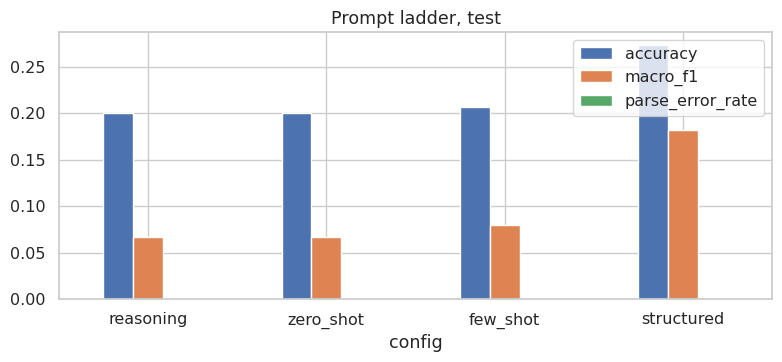

In [85]:
display(ladder.round(3))
ladder.set_index("config")[["accuracy", "macro_f1", "parse_error_rate"]].plot(kind="bar", figsize=(8, 3.8), rot=0)
plt.title("Prompt ladder, test")
plt.tight_layout()
plt.show()


### Сравнение с исполнителями


На тех же test `task_id`: модель vs каждый человек, модель vs majority vote, человек vs majority vote, модель vs эталон, агрегация vs эталон.


In [86]:
best_config = ladder.sort_values("macro_f1", ascending=False).iloc[0]["config"]
model_test = model_pred[(model_pred["config"] == best_config) & (model_pred["split"] == "test")].copy()
model_map = model_test.set_index("task_id")["label"]

cmp_rows = []
test_answers = accepted[accepted["task_id"].isin(split_manifest["test"])]

for performer, g in test_answers.groupby("performer_id"):
    merged = g.merge(model_test[["task_id", "label"]].rename(columns={"label": "model_label"}), on="task_id")
    cmp_rows.append({
        "comparison": f"модель vs {performer}",
        "n": len(merged),
        "agreement": float((merged["label"] == merged["model_label"]).mean()),
        "cohen_kappa": safe_kappa(merged["label"], merged["model_label"]),
    })

mv_vs_model = mv_test.merge(model_test[["task_id", "label"]].rename(columns={"label": "model_label"}), on="task_id")
cmp_rows.append({
    "comparison": "модель vs majority vote",
    "n": len(mv_vs_model),
    "agreement": float((mv_vs_model["mv_label"] == mv_vs_model["model_label"]).mean()),
    "cohen_kappa": safe_kappa(mv_vs_model["mv_label"], mv_vs_model["model_label"]),
})
cmp_rows.append({
    "comparison": "модель vs эталон",
    "n": int(model_test["parse_ok"].sum()),
    "agreement": quality_report(model_test["golden_label"], model_test["label"])["accuracy"],
    "cohen_kappa": np.nan,
})
cmp_rows.append({
    "comparison": "majority vote vs эталон",
    "n": len(mv_test),
    "agreement": human_mv_report["accuracy"],
    "cohen_kappa": np.nan,
})
display(pd.DataFrame(cmp_rows).round(3))
print("лучшая prompt-конфигурация для замены голоса:", best_config)


,comparison,n,agreement,cohen_kappa
0,модель vs w_anna,93,0.258,0.083
1,модель vs w_boris,93,0.258,0.119
2,модель vs w_chen,89,0.236,0.034
3,модель vs w_dina,88,0.250,0.075
4,модель vs w_erik,78,0.218,0.066
5,модель vs majority vote,150,0.267,0.083
6,модель vs эталон,150,0.273,NaN
7,majority vote vs эталон,150,0.787,NaN


лучшая prompt-конфигурация для замены голоса: structured


### Замена одного исполнителя


Для каждого объекта удаляем один человеческий голос и ставим голос модели. Сначала один seed — чтобы увидеть таблицу.


In [87]:
def replace_one_worker_with_model(
    human_answers: pd.DataFrame,
    model_labels: pd.DataFrame,
    seed: int,
) -> pd.DataFrame:
    """На каждом объекте выкинуть одного случайного человека и поставить голос модели.

    seed фиксируем, чтобы повтор ячейки дал те же числа. Несколько seed в ноутбуке —
    чтобы увидеть разброс, а не один удачный жребий.
    """
    rng = np.random.default_rng(seed)
    rows = []
    model_map = model_labels.set_index("task_id")["label"].to_dict()
    for task_id, group in human_answers.groupby("task_id"):
        valid = group[group["label"].isin(LABELS)].copy()
        if valid.empty:
            continue
        drop_idx = rng.integers(0, len(valid))
        kept = valid.drop(valid.index[drop_idx])  # двое людей остаются
        model_label = model_map.get(task_id)
        hybrid = pd.concat(
            [
                kept[["task_id", "label"]],
                pd.DataFrame([{"task_id": task_id, "label": model_label}]),
            ],
            ignore_index=True,
        )
        mv = majority_vote(hybrid).iloc[0]
        rows.append({"task_id": task_id, "hybrid_label": mv["mv_label"], "n_votes": mv["n_votes"]})
    return pd.DataFrame(rows)


In [88]:
human_test = accepted[accepted["task_id"].isin(split_manifest["test"])]
gold_test = dataset[dataset["task_id"].isin(split_manifest["test"])][["task_id", "golden_label"]]
hybrid_one = replace_one_worker_with_model(human_test, model_test, seed=0)
merged_one = hybrid_one.merge(gold_test, on="task_id")
display(merged_one.head(8))
print("acc seed=0:", round(accuracy_score(merged_one["golden_label"], merged_one["hybrid_label"]), 3))


,task_id,hybrid_label,n_votes,golden_label
0,task_010b21d66d72,negative,3,negative
1,task_02d47fd87598,skip,3,skip
2,task_061ffec32108,skip,3,skip
3,task_06758f4237d6,negative,3,negative
4,task_08e24314ec08,speech,3,positive
5,task_09848d005596,skip,3,skip
6,task_0b881786942d,positive,3,positive
7,task_0cb63d2d5a21,neutral,3,negative


acc seed=0: 0.687


Несколько seed: какого человека выкинули — случайность, смотрим среднее и разброс.


In [89]:
seeds = list(range(7))
hybrid_stats = []

for seed in seeds:
    hybrid = replace_one_worker_with_model(human_test, model_test, seed=seed)
    merged = hybrid.merge(gold_test, on="task_id")
    merged = merged[merged["hybrid_label"].isin(LABELS)]
    hybrid_stats.append({
        "seed": seed,
        "accuracy": accuracy_score(merged["golden_label"], merged["hybrid_label"]),
        "macro_f1": f1_score(merged["golden_label"], merged["hybrid_label"], average="macro", labels=list(LABELS), zero_division=0),
    })
hybrid_df = pd.DataFrame(hybrid_stats)
display(hybrid_df.round(3))
print(
    "mean acc", round(hybrid_df["accuracy"].mean(), 3),
    "std", round(hybrid_df["accuracy"].std(), 3),
)

print(
    "mean f1 ", round(hybrid_df["macro_f1"].mean(), 3),
    "std", round(hybrid_df["macro_f1"].std(), 3),
)

# Урезанное перекрытие: два оставшихся человека, без модели, тот же набор seed

reduced_stats = []
rng = np.random.default_rng(0)

for seed in seeds:
    rows = []
    local = np.random.default_rng(seed)
    for task_id, g in human_test.groupby("task_id"):
        g = g[g["label"].isin(LABELS)]
        if len(g) < 2:
            continue
        drop_idx = local.integers(0, len(g))
        kept = g.drop(g.index[drop_idx])
        rows.append({"task_id": task_id, "label": kept["label"].mode().iloc[0]})
    reduced = pd.DataFrame(rows).merge(gold_test, on="task_id")
    reduced_stats.append({
        "seed": seed,
        "accuracy": accuracy_score(reduced["golden_label"], reduced["label"]),
        "macro_f1": f1_score(reduced["golden_label"], reduced["label"], average="macro", labels=list(LABELS), zero_division=0),
    })
reduced_df = pd.DataFrame(reduced_stats)

model_cost_test = estimate_cost(
    model_test["n_input_tokens"].sum(),
    model_test["n_output_tokens"].sum(),
    model_test["model_name"].iloc[0],
)["model_cost"]
log_scheme(
    "Модель вместо одного человека",
    {"accuracy": float(hybrid_df["accuracy"].mean()), "macro_f1": float(hybrid_df["macro_f1"].mean())},
    coverage=1.0,
    human_assignments=2,
    cost=2 * len(split_manifest["test"]) * HUMAN_COST_PER_ASSIGNMENT + model_cost_test,
    tokens=int(model_test["n_input_tokens"].sum() + model_test["n_output_tokens"].sum()),
    latency=float(model_test["latency_sec"].mean()),
)

print("MV overlap=3 acc=", round(human_mv_report["accuracy"], 3),
      "| overlap≈2 acc=", round(reduced_df["accuracy"].mean(), 3),
      "| hybrid acc=", round(hybrid_df["accuracy"].mean(), 3))


,seed,accuracy,macro_f1
0,0,0.687,0.685
1,1,0.727,0.728
2,2,0.660,0.663
3,3,0.700,0.703
4,4,0.680,0.686
5,5,0.667,0.665
6,6,0.693,0.697


mean acc 0.688 std 0.022
mean f1  0.69 std 0.023
MV overlap=3 acc= 0.787 | overlap≈2 acc= 0.658 | hybrid acc= 0.688


# Блок 5. Уверенность и гибридная разметка


Текстовую самооценку модели («я уверена на 90%») **не считаем** откалиброванной вероятностью. Рабочие варианты:


- вероятность выбранного класса из нормализованных логитов допустимых меток (`confidence`);
- разница вероятностей двух лучших классов (`margin`);
- согласованность нескольких стохастических прогонов;
- согласованность модели с человеческими голосами.


Порог выбирается **только на calibration**, test смотрим после.


In [90]:
# ---------------------------------------------------------------------------
# Hybrid routing
# ---------------------------------------------------------------------------

def pick_threshold(calibration: pd.DataFrame, metric: str = "macro_f1", min_coverage: float = 0.2) -> dict:
    """Подобрать порог уверенности только на calibration.

    Идём по порогам от 0.50 до 0.99 и берём тот, где macro-F1 максимален,
    но автоматизация покрывает хотя бы min_coverage объектов.
    Test в эту функцию передавать нельзя — иначе порог подгонится под ответы, которые потом «оцениваем».
    """
    rows = []
    for thr in np.round(np.linspace(0.50, 0.99, 50), 3):
        auto = calibration[calibration["confidence"] >= thr]
        if auto.empty:
            rows.append({"threshold": float(thr), "coverage": 0.0, "accuracy": np.nan, "macro_f1": np.nan, "n_auto": 0})
            continue
        report = quality_report(auto["golden_label"], auto["label"])
        rows.append(
            {
                "threshold": float(thr),
                "coverage": float(len(auto) / len(calibration)),
                "accuracy": report["accuracy"],
                "macro_f1": report["macro_f1"],
                "n_auto": int(len(auto)),
            }
        )
    curve = pd.DataFrame(rows)
    eligible = curve[curve["coverage"] >= min_coverage].dropna(subset=[metric])
    if eligible.empty:
        best = curve.dropna(subset=[metric]).sort_values(metric, ascending=False).head(1)
    else:
        best = eligible.sort_values(metric, ascending=False).head(1)
    chosen = float(best["threshold"].iloc[0]) if len(best) else 0.8
    return {"threshold": chosen, "curve": curve, "min_coverage": min_coverage, "metric": metric}


In [91]:
cal = model_pred[(model_pred["config"] == best_config) & (model_pred["split"] == "calibration")].copy()
chosen = pick_threshold(cal, metric="macro_f1", min_coverage=0.25)
threshold = chosen["threshold"]
curve = chosen["curve"]
print("выбранный порог:", threshold)
print("правило: max macro-F1 при coverage ≥ 0.25 на calibration")


выбранный порог: 0.95
правило: max macro-F1 при coverage ≥ 0.25 на calibration


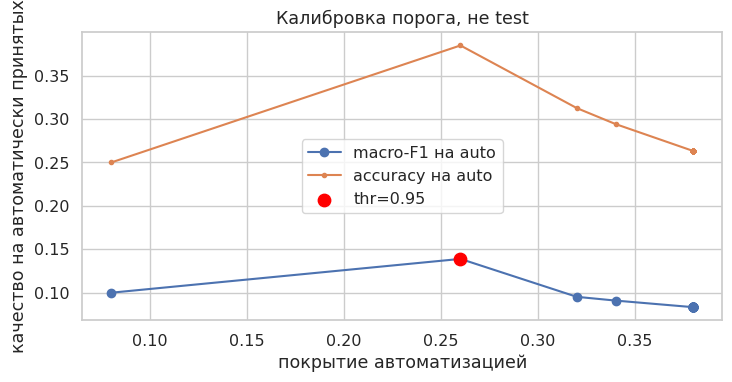

In [92]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(curve["coverage"], curve["macro_f1"], marker="o", label="macro-F1 на auto")
ax.plot(curve["coverage"], curve["accuracy"], marker=".", label="accuracy на auto")
best_point = curve.iloc[(curve["threshold"] - threshold).abs().argmin()]
ax.scatter([best_point["coverage"]], [best_point["macro_f1"]], s=80, color="red", zorder=5, label=f"thr={threshold}")
ax.set_xlabel("покрытие автоматизацией")
ax.set_ylabel("качество на автоматически принятых")
ax.legend()
ax.set_title("Калибровка порога, не test")
plt.tight_layout()
plt.show()


In [93]:
display(curve.iloc[::5].round(3))


,threshold,coverage,accuracy,macro_f1,n_auto
0,0.50,0.38,0.263,0.083,19
5,0.55,0.38,0.263,0.083,19
10,0.60,0.38,0.263,0.083,19
15,0.65,0.38,0.263,0.083,19
20,0.70,0.38,0.263,0.083,19
25,0.75,0.38,0.263,0.083,19
30,0.80,0.38,0.263,0.083,19
35,0.85,0.38,0.263,0.083,19
40,0.90,0.38,0.263,0.083,19
45,0.95,0.26,0.385,0.139,13


На test порог уже заморожен. Сначала готовим таблицу предсказаний модели и флаг `confident`.


In [94]:
test_m = model_pred[(model_pred["config"] == best_config) & (model_pred["split"] == "test")].copy()
test_m = test_m.merge(mv_test[["task_id", "mv_label", "n_votes"]], on="task_id")
test_m["confident"] = test_m["confidence"] >= threshold
coverage_conf = float(test_m["confident"].mean())
print("покрытие автоматизацией:", round(coverage_conf, 3))
print("уверенных объектов:", int(test_m["confident"].sum()), "из", len(test_m))
test_m[["task_id", "golden_label", "label", "confidence", "confident", "mv_label"]].head(8)


покрытие автоматизацией: 0.333
уверенных объектов: 50 из 150


,task_id,golden_label,label,confidence,confident,mv_label
0,task_bd9a1add7244,negative,positive,0.000077,False,negative
1,task_c7a9d4f45748,skip,speech,0.969351,True,neutral
2,task_6d706b9b2ddf,skip,positive,0.000064,False,skip
3,task_6371472d66f6,neutral,positive,0.000044,False,neutral
4,task_13a54f3f7fd6,skip,positive,0.000050,False,neutral
5,task_bc25d2233b25,positive,speech,0.944951,False,positive
6,task_662faadd8fcc,neutral,positive,0.000060,False,neutral
7,task_63afa5c8ddad,negative,speech,0.950935,True,negative


### Схема 1. Модель размечает всё


In [95]:
report_all = quality_report(test_m["golden_label"], test_m["label"])
print({k: report_all[k] for k in ["accuracy", "macro_f1", "n_valid"]})


{'accuracy': 0.2733333333333333, 'macro_f1': 0.18160935280121876, 'n_valid': 150}


### Схема 2. Гибрид с порогом


Если `confident` — берём модель, иначе majority vote людей.


In [96]:
hybrid_conf = np.where(test_m["confident"], test_m["label"], test_m["mv_label"])
report_conf = quality_report(test_m["golden_label"], hybrid_conf)
human_assign_conf = (1 - coverage_conf) * 3
print("macro_f1:", round(report_conf["macro_f1"], 3))
print("среднее число людей на объект:", round(human_assign_conf, 2))


macro_f1: 0.637
среднее число людей на объект: 2.0


### Схема 3. Модель как дополнительный голос при уверенности


In [97]:
extra_rows = []

for rec in test_m.itertuples(index=False):
    human_g = human_test[human_test["task_id"] == rec.task_id][["task_id", "label"]]
    if rec.confident:
        human_g = pd.concat([human_g, pd.DataFrame([{"task_id": rec.task_id, "label": rec.label}])], ignore_index=True)
    extra_rows.append(majority_vote(human_g).iloc[0])
scheme3 = pd.DataFrame(extra_rows)
report3 = quality_report(test_m["golden_label"], scheme3["mv_label"])
print({k: report3[k] for k in ["accuracy", "macro_f1", "n_valid"]})


{'accuracy': 0.8, 'macro_f1': 0.8029629629629629, 'n_valid': 150}


### Схема 4. Больше людей при неуверенности


Качество на спорных объектах остаётся как у MV, но стоимость растёт — учебная прокси «добрали перекрытие до 5».


In [98]:
human_assign_boost = np.where(test_m["confident"], 3, 5)
print("среднее число людей на объект:", round(float(np.mean(human_assign_boost)), 2))
print("качество как у MV людей:", {k: human_mv_report[k] for k in ["accuracy", "macro_f1"]})


среднее число людей на объект: 4.33
качество как у MV людей: {'accuracy': 0.7866666666666666, 'macro_f1': 0.7897727272727273}


### Схема 5. Замена одного человека только выше порога


In [99]:
scheme5_labels = []
local = np.random.default_rng(0)

for rec in test_m.itertuples(index=False):
    g = human_test[human_test["task_id"] == rec.task_id]
    g = g[g["label"].isin(LABELS)]
    if rec.confident and len(g):
        drop_idx = local.integers(0, len(g))
        kept = g.drop(g.index[drop_idx])
        kept = pd.concat([kept[["task_id", "label"]], pd.DataFrame([{"task_id": rec.task_id, "label": rec.label}])])
        scheme5_labels.append(majority_vote(kept).iloc[0]["mv_label"])
    else:
        scheme5_labels.append(rec.mv_label)
report5 = quality_report(test_m["golden_label"], scheme5_labels)
print({k: report5[k] for k in ["accuracy", "macro_f1", "n_valid"]})


{'accuracy': 0.74, 'macro_f1': 0.7431152409234602, 'n_valid': 150}


Сводная таблица всех схем на test.


In [100]:
auto_cost = estimate_cost(test_m["n_input_tokens"].sum(), test_m["n_output_tokens"].sum(), test_m["model_name"].iloc[0])
n_test = len(test_m)

schemes_cost = pd.DataFrame([
    {"scheme": "модель размечает всё", "accuracy": report_all["accuracy"], "macro_f1": report_all["macro_f1"],
     "coverage": 1.0, "human_assignments": 0, "cost": auto_cost["total_cost"]},
    {"scheme": "гибрид с порогом (auto | люди)", "accuracy": report_conf["accuracy"], "macro_f1": report_conf["macro_f1"],
     "coverage": coverage_conf, "human_assignments": human_assign_conf,
     "cost": auto_cost["model_cost"] + human_assign_conf * n_test * HUMAN_COST_PER_ASSIGNMENT},
    {"scheme": "модель как доп. голос при уверенности", "accuracy": report3["accuracy"], "macro_f1": report3["macro_f1"],
     "coverage": coverage_conf, "human_assignments": 3,
     "cost": auto_cost["model_cost"] + 3 * n_test * HUMAN_COST_PER_ASSIGNMENT},
    {"scheme": "больше людей при неуверенности", "accuracy": human_mv_report["accuracy"], "macro_f1": human_mv_report["macro_f1"],
     "coverage": coverage_conf, "human_assignments": float(np.mean(human_assign_boost)),
     "cost": auto_cost["model_cost"] + float(np.mean(human_assign_boost)) * n_test * HUMAN_COST_PER_ASSIGNMENT},
    {"scheme": "замена человека только выше порога", "accuracy": report5["accuracy"], "macro_f1": report5["macro_f1"],
     "coverage": coverage_conf, "human_assignments": 2 * coverage_conf + 3 * (1 - coverage_conf),
     "cost": auto_cost["model_cost"] + (2 * coverage_conf + 3 * (1 - coverage_conf)) * n_test * HUMAN_COST_PER_ASSIGNMENT},
])
display(schemes_cost.round(3))


,scheme,accuracy,macro_f1,coverage,human_assignments,cost
0,модель размечает всё,0.273,0.182,1.000,0.000,0.0
1,гибрид с порогом (auto | люди),0.627,0.637,0.333,2.000,300.0
2,модель как доп. голос при уверенности,0.800,0.803,0.333,3.000,450.0
3,больше людей при неуверенности,0.787,0.790,0.333,4.333,650.0
4,замена человека только выше порога,0.740,0.743,0.333,2.667,400.0


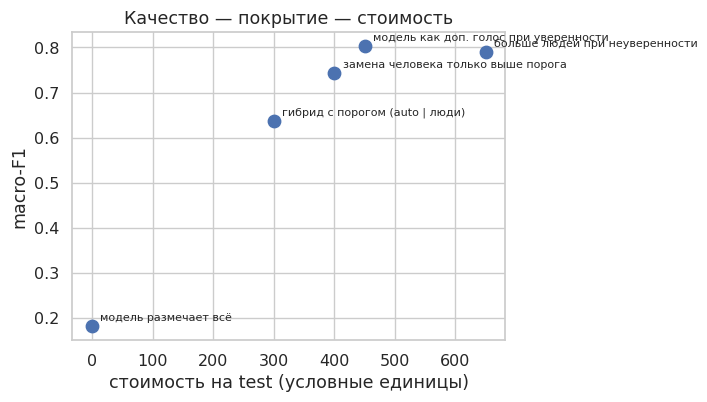

In [101]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.scatter(schemes_cost["cost"], schemes_cost["macro_f1"], s=80)

for _, r in schemes_cost.iterrows():
    ax.annotate(r["scheme"], (r["cost"], r["macro_f1"]), fontsize=8, xytext=(6, 4), textcoords="offset points")
ax.set_xlabel("стоимость на test (условные единицы)")
ax.set_ylabel("macro-F1")
ax.set_title("Качество — покрытие — стоимость")
plt.tight_layout()
plt.show()


In [102]:
log_scheme(
    "Гибрид с порогом",
    report_conf,
    coverage=coverage_conf,
    parse_errors=float((~test_m["parse_ok"]).mean()),
    human_assignments=human_assign_conf,
    tokens=int(test_m["n_input_tokens"].sum() + test_m["n_output_tokens"].sum()),
    cost=float(schemes_cost.loc[schemes_cost["scheme"].str.contains("гибрид"), "cost"].iloc[0]),
    latency=float(test_m["latency_sec"].mean()),
)

print("правило маршрутизации: если confidence ≥", threshold, "берём модель, иначе majority vote людей")


правило маршрутизации: если confidence ≥ 0.95 берём модель, иначе majority vote людей


# Блок 6. Ансамбль и итоговое сравнение


Три небольшие модели с Hugging Face: `Qwen3-0.6B`, `Qwen2.5-0.5B-Instruct`, `Phi-3.5-mini-instruct`. Смотрим, где они согласны — там автоматизация дешёвая. Где систематически расходятся — спорные объекты выгоднее отдать людям, чем усложнять промпт.


In [103]:
ens = pd.read_parquet(FILES["ensemble_predictions"])
ens_test = ens[ens["split"] == "test"].copy()
print("моделей в ансамбле:", ens_test["model_name"].nunique())
print("ответов на test:", len(ens_test))
ens_test.head(5)


моделей в ансамбле: 3
ответов на test: 450


,task_id,split,config,model_name,backend,label,raw,parse_ok,parse_reason,confidence,margin,n_input_tokens,n_output_tokens,latency_sec,golden_label,p_positive,p_negative,p_neutral,p_speech,p_skip
50,task_bd9a1add7244,test,structured,hf/Qwen/Qwen3-0.6B,hf,skip,"{""label"": ""skip""}",True,json,0.535919,0.300725,321,15,0.299,negative,0.066687,0.068226,0.235193,0.093974,0.535919
51,task_c7a9d4f45748,test,structured,hf/Qwen/Qwen3-0.6B,hf,skip,"{""label"": ""skip""}",True,json,0.775287,0.584511,184,16,0.300,skip,0.190776,0.003157,0.018442,0.012338,0.775287
52,task_6d706b9b2ddf,test,structured,hf/Qwen/Qwen3-0.6B,hf,skip,"{""label"": ""skip""}",True,json,0.938021,0.901276,186,5,0.377,skip,0.006250,0.002442,0.016541,0.036745,0.938021
53,task_6371472d66f6,test,structured,hf/Qwen/Qwen3-0.6B,hf,neutral,"{""label"": ""neutral""}",True,json,0.848115,0.756145,186,5,0.528,neutral,0.036179,0.002972,0.848115,0.020764,0.091969
54,task_13a54f3f7fd6,test,structured,hf/Qwen/Qwen3-0.6B,hf,skip,"{""label"": ""skip""}",True,json,0.899594,0.853067,186,15,0.286,skip,0.046527,0.045708,0.003151,0.005021,0.899594


In [104]:
pivot = ens_test.pivot_table(index="task_id", columns="model_name", values="label", aggfunc="first")
display(pivot.head())


model_name,hf/Qwen/Qwen2.5-0.5B-Instruct,hf/Qwen/Qwen3-0.6B,hf/microsoft/Phi-3.5-mini-instruct
task_id,,,
task_010b21d66d72,negative,negative,negative
task_02d47fd87598,skip,skip,skip
task_061ffec32108,neutral,skip,skip
task_06758f4237d6,negative,negative,negative
task_08e24314ec08,positive,positive,positive


Попарное согласие моделей на одних и тех же `task_id`.


In [105]:
pair_rows = []

for a, b in combinations(pivot.columns, 2):
    mask = pivot[a].isin(LABELS) & pivot[b].isin(LABELS)
    pair_rows.append({
        "a": a, "b": b, "n": int(mask.sum()),
        "agreement": float((pivot.loc[mask, a] == pivot.loc[mask, b]).mean()),
        "cohen_kappa": safe_kappa(pivot.loc[mask, a], pivot.loc[mask, b]),
    })
display(pd.DataFrame(pair_rows).round(3))


,a,b,n,agreement,cohen_kappa
0,hf/Qwen/Qwen2.5-0.5B-Instruct,hf/Qwen/Qwen3-0.6B,146,0.445,0.302
1,hf/Qwen/Qwen2.5-0.5B-Instruct,hf/microsoft/Phi-3.5-mini-instruct,146,0.459,0.318
2,hf/Qwen/Qwen3-0.6B,hf/microsoft/Phi-3.5-mini-instruct,148,0.514,0.389


Где все модели сошлись — и где остались споры.


In [106]:
full_agree = (pivot.nunique(axis=1) == 1) & pivot.notna().all(axis=1)
print("доля полного согласия ансамбля:", round(float(full_agree.mean()), 3))
disputed = pivot[~full_agree].copy()
disputed["golden_label"] = disputed.index.map(gold)
print("спорные объекты:", len(disputed))
display(disputed.head(8))


доля полного согласия ансамбля: 0.273
спорные объекты: 109


model_name,hf/Qwen/Qwen2.5-0.5B-Instruct,hf/Qwen/Qwen3-0.6B,hf/microsoft/Phi-3.5-mini-instruct,golden_label
task_id,,,,
task_061ffec32108,neutral,skip,skip,skip
task_09848d005596,neutral,skip,skip,skip
task_0b881786942d,positive,positive,neutral,positive
task_0cb63d2d5a21,skip,negative,negative,negative
task_10b2f6dbaed4,neutral,speech,speech,speech
task_10eeb94f00d8,positive,neutral,neutral,neutral
task_121e3af13467,speech,speech,neutral,speech
task_13a54f3f7fd6,skip,skip,speech,skip


Majority vote по голосам моделей на test.


In [107]:
ens_votes = ens_test[ens_test["parse_ok"]][["task_id", "label"]]
ens_mv = majority_vote(ens_votes)
ens_mv = ens_mv.merge(dataset[["task_id", "golden_label", "split"]], on="task_id")
ens_mv_test = ens_mv[ens_mv["split"] == "test"]
ens_report = quality_report(ens_mv_test["golden_label"], ens_mv_test["mv_label"])
print("majority vote ансамбля:", {k: ens_report[k] for k in ["accuracy", "macro_f1", "n_valid"]})


majority vote ансамбля: {'accuracy': 0.8, 'macro_f1': 0.7991222491592667, 'n_valid': 150}


Маршрутизация: согласованные объекты — голос ансамбля, спорные — majority vote людей.


In [108]:
route = ens_mv_test.merge(full_agree.rename("full_agree"), left_on="task_id", right_index=True)
route = route.merge(mv_test[["task_id", "mv_label"]].rename(columns={"mv_label": "human_mv"}), on="task_id")
route["final"] = np.where(route["full_agree"], route["mv_label"], route["human_mv"])
route_report = quality_report(route["golden_label"], route["final"])
print("ансамбль + люди на спорах:", {k: route_report[k] for k in ["accuracy", "macro_f1"]})
display(route[["task_id", "golden_label", "full_agree", "mv_label", "human_mv", "final"]].head(8))


ансамбль + люди на спорах: {'accuracy': 0.8466666666666667, 'macro_f1': 0.8483326982094589}


,task_id,golden_label,full_agree,mv_label,human_mv,final
0,task_bd9a1add7244,negative,False,negative,negative,negative
1,task_c7a9d4f45748,skip,False,skip,neutral,neutral
2,task_6d706b9b2ddf,skip,False,skip,skip,skip
3,task_6371472d66f6,neutral,False,neutral,neutral,neutral
4,task_13a54f3f7fd6,skip,False,skip,neutral,neutral
5,task_bc25d2233b25,positive,False,speech,positive,positive
6,task_662faadd8fcc,neutral,True,neutral,neutral,neutral
7,task_63afa5c8ddad,negative,False,negative,negative,negative


In [109]:
ens_cost = estimate_cost(
    ens_test["n_input_tokens"].sum(), ens_test["n_output_tokens"].sum(),
    "hf/Qwen/Qwen3-0.6B",
)

log_scheme(
    "Ансамбль моделей",
    ens_report,
    coverage=1.0,
    parse_errors=float((~ens_test["parse_ok"]).mean()),
    human_assignments=0,
    tokens=int(ens_test["n_input_tokens"].sum() + ens_test["n_output_tokens"].sum()),
    cost=float(ens_cost["total_cost"]),
    latency=float(ens_test["latency_sec"].mean()),
)


{'scheme': 'Ансамбль моделей',
 'accuracy': 0.8,
 'macro_f1': 0.7991222491592667,
 'coverage': 1.0,
 'parse_errors': 0.011111111111111112,
 'human_assignments': 0,
 'tokens': 102228,
 'cost': 0.0,
 'latency': 0.39812}

## Итоговый leaderboard


Стоимость в таблице — сумма на весь test: модельные токены плюс человеческие назначения. `human_assignments` — сколько людей нужно на один объект. Задержку заранее выполненных прогонов берём из журнала, а не измеряем при чтении файлов.


Участники выбирают не «лучшую модель», а **схему под ограничение**: максимальное качество, ограниченный бюджет, скорость или минимум людей. Ошибки модели и людей могут коррелировать — тогда ансамбль из модели и тех же людей даёт меньше, чем кажется. Смена датасета требует новой проверки всех выводов.


In [110]:
leaderboard = pd.DataFrame(experiment_log)
order = [
    "Один человек (среднее)",
    "Majority vote людей",
    "Модель zero-shot",
    "Модель few-shot",
    "Модель reasoning",
    "Модель structured",
    "Модель вместо одного человека",
    "Гибрид с порогом",
    "Ансамбль моделей",
]

leaderboard["scheme"] = pd.Categorical(leaderboard["scheme"], categories=order, ordered=True)
leaderboard = leaderboard.dropna(subset=["scheme"]).drop_duplicates("scheme", keep="last").sort_values("scheme")
display(leaderboard.round(3))


,scheme,accuracy,macro_f1,coverage,parse_errors,human_assignments,tokens,cost,latency
0,Один человек (среднее),0.686,0.687,1.000,0.000,1.0,0,150.0,NaN
1,Majority vote людей,0.787,0.790,1.000,0.000,3.0,0,450.0,NaN
5,Модель zero-shot,0.200,0.067,1.000,0.000,0.0,68161,0.0,3.298
2,Модель few-shot,0.207,0.080,1.000,0.000,0.0,108211,0.0,5.495
3,Модель reasoning,0.200,0.067,1.000,0.000,0.0,72361,0.0,3.624
4,Модель structured,0.273,0.182,1.000,0.000,0.0,73083,0.0,4.071
6,Модель вместо одного человека,0.688,0.690,1.000,0.000,2.0,73083,300.0,4.071
7,Гибрид с порогом,0.627,0.637,0.333,0.000,2.0,73083,300.0,4.071
8,Ансамбль моделей,0.800,0.799,1.000,0.011,0.0,102228,0.0,0.398


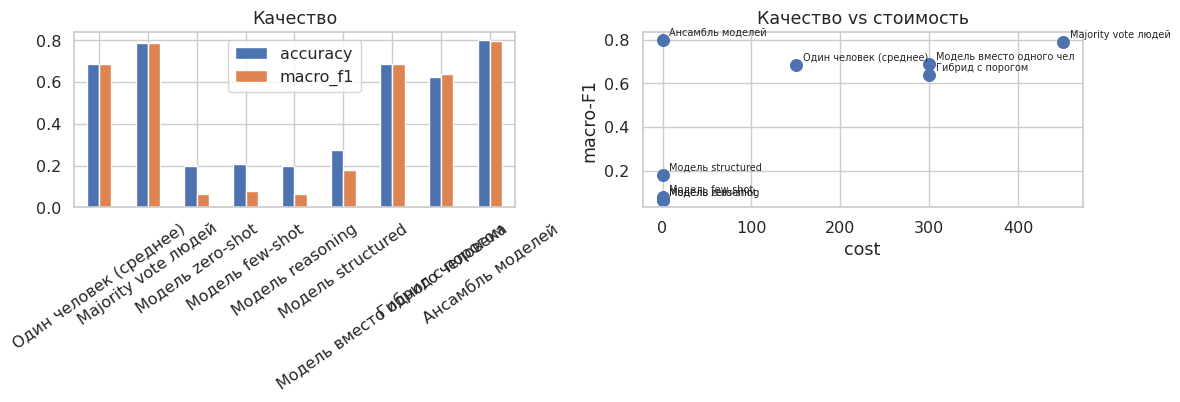

порог уверенности: 0.95
лучшая prompt-конфигурация: structured
сохранено: /content/artifacts/leaderboard.csv


In [111]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
lb = leaderboard.dropna(subset=["scheme"]).copy()
lb.plot(x="scheme", y=["accuracy", "macro_f1"], kind="bar", ax=axes[0], rot=35)
axes[0].set_title("Качество")
axes[0].set_xlabel("")
axes[1].scatter(lb["cost"], lb["macro_f1"], s=70)

for _, r in lb.iterrows():
    if pd.notna(r["cost"]) and pd.notna(r["macro_f1"]):
        axes[1].annotate(str(r["scheme"])[:24], (r["cost"], r["macro_f1"]), fontsize=7, xytext=(5, 3), textcoords="offset points")
axes[1].set_xlabel("cost")
axes[1].set_ylabel("macro-F1")
axes[1].set_title("Качество vs стоимость")
fig.tight_layout()
plt.show()

leaderboard.to_csv(FILES["leaderboard"], index=False)
print("порог уверенности:", threshold)
print("лучшая prompt-конфигурация:", best_config)
print("сохранено:", FILES["leaderboard"])


## Вопросы для обсуждения


1. Какую схему выберете, если важнее максимальное качество? Если бюджет жёсткий? Если разметка нужна сегодня вечером?
2. Где ошибки модели совпадают с ошибками людей — и что это говорит про инструкцию, а не про модель?
3. Что из сегодняшней таблицы нельзя перенести на новый датасет без повторной калибровки?
4. Почему few-shot примеры запрещено брать из test, даже если «так качество промпта лучше видно»?


## Критерии успешности занятия — чеклист


К этому моменту связаны одним `task_id`:


- [ ] профиль датасета и `split_manifest`
- [ ] код отправки в Яндекс Задания
- [ ] человеческие ответы и оценка качества
- [ ] локальный HF-инференс и сборка промпта
- [ ] сравнение prompt-конфигураций
- [ ] замена одного исполнителя
- [ ] порог, выбранный на calibration
- [ ] проверка ансамбля
- [ ] финальная таблица качества, цены и скорости


In [112]:
!zip -r artifacts.zip artifacts

  adding: artifacts/ (stored 0%)
  adding: artifacts/human_aggregation.parquet (deflated 42%)
  adding: artifacts/split_manifest.json (deflated 66%)
  adding: artifacts/human_answers.parquet (deflated 39%)
  adding: artifacts/yatasks_entities.json (deflated 35%)
  adding: artifacts/dataset_prepared.parquet (deflated 24%)
  adding: artifacts/ensemble_predictions.parquet (deflated 27%)
  adding: artifacts/model_predictions.parquet (deflated 32%)
  adding: artifacts/leaderboard.csv (deflated 53%)
  adding: artifacts/call_log.parquet (deflated 32%)


In [113]:
from google.colab import files
files.download('artifacts.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>